## Phase 0: Environment Setup

In [112]:
import logging, os, sys, openpyxl, xlrd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [113]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[
        logging.FileHandler("pipeline.log"),
        logging.StreamHandler(sys.stdout)
    ]
)

In [114]:
print(os.getcwd())
logging.info("Current working directory: %s", os.getcwd())

d:\Abdulrhman\DEPI\Python Workspace\projects
2026-08-30 20:30:13,582 | INFO | Current working directory: d:\Abdulrhman\DEPI\Python Workspace\projects


# Phase 1: Data Loading & Initial Inspection

## 1.1 Import Data from Excel

In [115]:
# 1.1 Import data from Excel
try:
    Orders = pd.read_excel(r"D:\Abdulrhman\DEPI\Datasets\Sample - Superstore 2019.xls", sheet_name="Orders")
    People = pd.read_excel(r"D:\Abdulrhman\DEPI\Datasets\Sample - Superstore 2019.xls", sheet_name="People")
    Returns = pd.read_excel(r"D:\Abdulrhman\DEPI\Datasets\Sample - Superstore 2019.xls", sheet_name="Returns")
    logging.info("Data imported successfully from Excel file: %s", r"D:\Abdulrhman\DEPI\Datasets\Sample - Superstore 2019.xls")
except Exception as e:
    logging.error("Failed to import data from Excel: %s", e)

2026-08-30 20:30:14,996 | INFO | Data imported successfully from Excel file: D:\Abdulrhman\DEPI\Datasets\Sample - Superstore 2019.xls


## 1.2 Inspect Dataset Structure and Metadata

### 1.2.1 Inspect Orders Dataset

In [116]:
# 1.2 Inspect dataset structure and metadata

logging.info("Starting dataset inspection")

# 1.2.1 Inspecting Orders dataset
print("Orders Shape:", Orders.shape)
print("Orders Columns:", Orders.columns.tolist())
print("Orders info:")
display(Orders.info(memory_usage="deep"))
print("\nOrders Sample:")
display(Orders.head(5))
print("\nOrders Random Sample:")
display(Orders.sample(5))

2026-08-30 20:30:15,009 | INFO | Starting dataset inspection
Orders Shape: (9994, 21)
Orders Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
Orders info:
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9994 non-null   int64         
 1   Order ID        9994 non-null   str           
 2   Order Date      9994 non-null   datetime64[us]
 3   Ship Date       9994 non-null   datetime64[us]
 4   Ship Mode       9994 non-null   str           
 5   Customer ID     9994 non-null   str           
 6   Customer Name   9994 non-null   str           
 7   Segment         9994 non-null   str           
 8

None


Orders Sample:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164



Orders Random Sample:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
4018,4019,CA-2017-165624,2017-08-23,2017-08-28,Standard Class,FH-14350,Fred Harton,Consumer,United States,Atlanta,...,30318.0,South,TEC-AC-10004568,Technology,Accessories,Maxell LTO Ultrium - 800 GB,251.910,9,0.0,47.8629
8393,8394,CA-2018-142594,2018-12-01,2018-12-06,Second Class,EJ-14155,Eva Jacobs,Consumer,United States,Franklin,...,2038.0,East,FUR-FU-10002045,Furniture,Furnishings,"Executive Impressions 14""",111.150,5,0.0,48.9060
3156,3157,CA-2017-139584,2017-08-24,2017-08-28,Standard Class,EM-13810,Eleni McCrary,Corporate,United States,New York City,...,10009.0,East,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,284.364,2,0.4,-75.8304
9746,9747,CA-2019-137505,2019-11-24,2019-11-24,Same Day,BP-11290,Beth Paige,Consumer,United States,Los Angeles,...,90008.0,West,FUR-TA-10001676,Furniture,Tables,Hon 61000 Series Interactive Training Tables,71.088,2,0.2,-1.7772
7408,7409,CA-2018-129728,2018-05-30,2018-06-06,Standard Class,JG-15310,Jason Gross,Corporate,United States,Los Angeles,...,90032.0,West,FUR-FU-10003247,Furniture,Furnishings,36X48 HARDFLOOR CHAIRMAT,167.840,8,0.0,11.7488


### 1.2.2 Inspect People Dataset

In [117]:
logging.info("Starting dataset inspection")

# 1.2.2 Inspecting People dataset
print("People Shape:", People.shape)
print("People Columns:", People.columns.tolist())
print("People info:")
display(People.info())
print("\nPeople Sample:")
display(People.head())

2026-08-30 20:30:15,121 | INFO | Starting dataset inspection
People Shape: (4, 2)
People Columns: ['Person', 'Region']
People info:
<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Person  4 non-null      str  
 1   Region  4 non-null      str  
dtypes: str(2)
memory usage: 196.0 bytes


None


People Sample:


,Person,Region
0,Anna Andreadi,West
1,Chuck Magee,East
2,Kelly Williams,Central
3,Cassandra Brandow,South


### 1.2.3 Inspect Returns Dataset

In [118]:
logging.info("Starting dataset inspection")

# 1.2.3 Inspecting Returns dataset
print("Returns Shape:", Returns.shape)
print("Returns Columns:", Returns.columns.tolist())
print("Returns info:")
display(Returns.info())
print("\nReturns Sample:")
display(Returns.head(5))
print("\nReturns Random Sample:")
display(Returns.sample(5))

2026-08-30 20:30:15,152 | INFO | Starting dataset inspection
Returns Shape: (800, 2)
Returns Columns: ['Returned', 'Order ID']
Returns info:
<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Returned  800 non-null    str  
 1   Order ID  800 non-null    str  
dtypes: str(2)
memory usage: 12.6 KB


None


Returns Sample:


,Returned,Order ID
0,Yes,CA-2016-100762
1,Yes,CA-2016-100762
2,Yes,CA-2016-100762
3,Yes,CA-2016-100762
4,Yes,CA-2016-100867



Returns Random Sample:


,Returned,Order ID
343,Yes,CA-2018-133368
211,Yes,CA-2017-146262
712,Yes,US-2017-160857
470,Yes,CA-2019-112753
173,Yes,CA-2017-132941


# Phase 2: Raw Data Quality Assessment

## 2.1 Orders Data Quality Assessment

In [119]:
# 2.1 Orders - Raw Data Quality Assessment

logging.info("Starting raw data quality Assessment")

# 2.1.1 Duplicate rows
print("Duplicate rows:", Orders.duplicated().sum())

# 2.1.2 Empty rows and columns
print("Empty rows:", Orders.isna().all(axis=1).sum())
print("Empty columns:", Orders.isna().all(axis=0).sum())

# 2.1.3 Missing values
print("\nMissing values:")
display(Orders.isna().sum())

# 2.1.4 Data types
print("\nData types:")
display(Orders.dtypes)

# 2.1.5 Valid values
print("\nInvalid values:")
print("Negative Sales:", (Orders["Sales"] < 0).sum())
print("Negative Quantity:", (Orders["Quantity"] < 0).sum())
print("Invalid Discount:", ((Orders["Discount"] < 0) | (Orders["Discount"] > 1)).sum())

# 2.1.6 Consistent categories
print("\nCategory values:")
print("Ship Mode:", Orders["Ship Mode"].unique())
print("Segment:", Orders["Segment"].unique())
print("Region:", Orders["Region"].unique())
print("Category:", Orders["Category"].unique())

# 2.1.7 Spaces
print("\nLeading/trailing or extra spaces:")

spaces_found = False
for col in Orders.select_dtypes(include="str").columns:
    spaces = Orders[col].astype(str).str.contains(
        r"^\s|\s$|\s{2,}",
        regex=True,
        na=False
    ).sum()
    if spaces > 0:
        print(f"{col}: {spaces}")
        spaces_found = True
if not spaces_found:
    print("no spaces found")

logging.info("Raw data quality checks completed successfully")

2026-08-30 20:30:15,193 | INFO | Starting raw data quality Assessment
Duplicate rows: 0
Empty rows: 0
Empty columns: 0

Missing values:


Row ID             0
Order ID           0
Order Date         0
Ship Date          0
Ship Mode          0
Customer ID        0
Customer Name      0
Segment            0
Country/Region     0
City               0
State              0
Postal Code       11
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales              0
Quantity           0
Discount           0
Profit             0
dtype: int64


Data types:


Row ID                     int64
Order ID                     str
Order Date        datetime64[us]
Ship Date         datetime64[us]
Ship Mode                    str
Customer ID                  str
Customer Name                str
Segment                      str
Country/Region               str
City                         str
State                        str
Postal Code              float64
Region                       str
Product ID                   str
Category                     str
Sub-Category                 str
Product Name                 str
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
dtype: object


Invalid values:
Negative Sales: 0
Negative Quantity: 0
Invalid Discount: 0

Category values:
Ship Mode: <StringArray>
['Second Class', 'Standard Class', 'First Class', 'Same Day']
Length: 4, dtype: str
Segment: <StringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str
Region: <StringArray>
['South', 'West', 'Central', 'East']
Length: 4, dtype: str
Category: <StringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str

Leading/trailing or extra spaces:
Product Name: 32
2026-08-30 20:30:15,431 | INFO | Raw data quality checks completed successfully


## 2.2 People Data Quality Assessment

In [120]:
# 2.2 People - Raw Data Quality Assessment

logging.info("Starting People raw data quality assessment")

# 2.2.1 Duplicate rows
print("\n1. Duplicate rows:", People.duplicated().sum())

# 2.2.2 Empty rows and columns
print("Empty rows:", People.isna().all(axis=1).sum())
print("Empty columns:", People.isna().all(axis=0).sum())

# 2.2.3 Missing values
print("\nMissing values:")
display(People.isna().sum())

# 2.2.4 Data types
print("\nData types:")
display(People.dtypes)

# 2.2.5 Consistent categories
print("\nCategory values:")
for col in People.select_dtypes(include="str").columns:
    print(f"{col}:", People[col].unique())

# 2.2.6 Spaces
print("\nLeading/trailing or extra spaces:")

spaces_found = False

for col in People.select_dtypes(include="str").columns:
    spaces = People[col].str.contains(
        r"^\s|\s$|\s{2,}",
        na=False
    ).sum()

    if spaces > 0:
        print(f"{col}: {spaces}")
        spaces_found = True

if not spaces_found:
    print("no spaces found")
logging.info("People raw data quality assessment completed successfully")

2026-08-30 20:30:15,449 | INFO | Starting People raw data quality assessment

1. Duplicate rows: 0
Empty rows: 0
Empty columns: 0

Missing values:


Person    0
Region    0
dtype: int64


Data types:


Person    str
Region    str
dtype: object


Category values:
Person: <StringArray>
['Anna Andreadi', 'Chuck Magee', 'Kelly Williams', 'Cassandra Brandow']
Length: 4, dtype: str
Region: <StringArray>
['West', 'East', 'Central', 'South']
Length: 4, dtype: str

Leading/trailing or extra spaces:
no spaces found
2026-08-30 20:30:15,465 | INFO | People raw data quality assessment completed successfully


## 2.3 Returns Data Quality Assessment

In [121]:
# 2.3 Returns - Raw Data Quality Assessment

logging.info("Starting Returns raw data quality assessment")

# 2.3.1 Duplicate rows
print("\nDuplicate rows:", Returns.duplicated().sum())

# 2.3.2 Empty rows and columns
print("Empty rows:", Returns.isna().all(axis=1).sum())
print("Empty columns:", Returns.isna().all(axis=0).sum())

# 2.3.3 Missing values
print("\nMissing values:")
display(Returns.isna().sum())

# 2.3.4 Data types
print("\nData types:")
display(Returns.dtypes)

# 2.3.5 Spaces
print("\nLeading/trailing or extra spaces:")

spaces_found = False
for col in Returns.select_dtypes(include="str").columns:
    spaces = Returns[col].str.contains(
        r"^\s|\s$|\s{2,}",
        regex=True,
        na=False
    ).sum()
    if spaces > 0:
        print(f"{col}: {spaces}")
        spaces_found = True

if not spaces_found:
    print("no spaces found")
logging.info("Returns raw data quality assessment completed successfully")

2026-08-30 20:30:15,483 | INFO | Starting Returns raw data quality assessment

Duplicate rows: 504
Empty rows: 0
Empty columns: 0

Missing values:


Returned    0
Order ID    0
dtype: int64


Data types:


Returned    str
Order ID    str
dtype: object


Leading/trailing or extra spaces:
no spaces found
2026-08-30 20:30:15,504 | INFO | Returns raw data quality assessment completed successfully


# Phase 3: Data Cleaning & Preparation

## 3.1 Data Type Correction

In [122]:
# 3.1 Data Type Correction
 
logging.info("Starting data type correction")

Orders["Postal Code"] = (Orders["Postal Code"].astype("Int64").astype("str"))

logging.info("Data type correction completed successfully")

2026-08-30 20:30:15,519 | INFO | Starting data type correction
2026-08-30 20:30:15,527 | INFO | Data type correction completed successfully


In [123]:
print("Data types:")
display(Orders.dtypes)


Data types:


Row ID                     int64
Order ID                     str
Order Date        datetime64[us]
Ship Date         datetime64[us]
Ship Mode                    str
Customer ID                  str
Customer Name                str
Segment                      str
Country/Region               str
City                         str
State                        str
Postal Code                  str
Region                       str
Product ID                   str
Category                     str
Sub-Category                 str
Product Name                 str
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
dtype: object

In [124]:
Orders.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 3.2 Missing Values Handling

In [125]:
# 3.2 Missing Values handling

logging.info("Starting missing values assessment")

# Count missing values in each column

missing_values = Orders.isna().sum()
display(missing_values[missing_values > 0])

logging.info(f"Missing values found in {len(missing_values[missing_values > 0])} column(s)")

2026-08-30 20:30:15,610 | INFO | Starting missing values assessment


Postal Code    11
dtype: int64

2026-08-30 20:30:15,629 | INFO | Missing values found in 1 column(s)


### 3.2.1 Identify Rows with Missing Postal Codes

In [126]:
# Find rows with missing Postal Code & state & city

missing_postal = Orders[Orders["Postal Code"].isna()]
display(missing_postal[["City", "State", "Postal Code"]])

,City,State,Postal Code
2234,Burlington,Vermont,NaN
5274,Burlington,Vermont,NaN
8798,Burlington,Vermont,NaN
9146,Burlington,Vermont,NaN
9147,Burlington,Vermont,NaN
9148,Burlington,Vermont,NaN
9386,Burlington,Vermont,NaN
9387,Burlington,Vermont,NaN
9388,Burlington,Vermont,NaN
9389,Burlington,Vermont,NaN


### 3.2.2 Validate Postal Code Information

In [127]:
# Check Postal Code for Burlington, Vermont

burlington_postal = Orders[(Orders["City"] == "Burlington") & (Orders["State"] == "Vermont")]
display(burlington_postal[["City", "State", "Postal Code"]])

,City,State,Postal Code
2234,Burlington,Vermont,NaN
5274,Burlington,Vermont,NaN
8798,Burlington,Vermont,NaN
9146,Burlington,Vermont,NaN
9147,Burlington,Vermont,NaN
9148,Burlington,Vermont,NaN
9386,Burlington,Vermont,NaN
9387,Burlington,Vermont,NaN
9388,Burlington,Vermont,NaN
9389,Burlington,Vermont,NaN


### 3.2.3 Fill Missing Postal Codes

In [128]:
# Fill missing Postal Codes

Orders["Postal Code"] = Orders["Postal Code"].fillna("05401")

### 3.2.4 Validate Missing Postal Codes

In [129]:
# Validate missing Postal Codes

missing = Orders.isna().sum()
display(missing)
logging.info(f"Remaining missing Postal Codes: {missing['Postal Code']}")

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State             0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

2026-08-30 20:30:15,725 | INFO | Remaining missing Postal Codes: 0


### 3.2.5 Create a Reusable Data Cleaning Class

In [130]:
# Create a reusable data cleaning class

class DataCleaner:
    def __init__(self, df):
        self.df = df

    # Remove extra spaces from a column
    def remove_extra_spaces(self, column):
        self.df[column] = self.df[column].str.strip().str.replace(r"\s{2,}", " ", regex=True)

        spaces = self.df[column].str.contains(r"^\s|\s$|\s{2,}", regex=True, na=False).sum()

        if spaces == 0:
            logging.info(f"Extra spaces fixed in {column}")
        else:
            logging.warning(f"Extra spaces still found in {column}: {spaces}")

    # Remove duplicate rows
    def remove_duplicates(self):
        duplicates = self.df.duplicated().sum()

        if duplicates > 0:
            self.df = self.df.drop_duplicates(inplace=True)
            logging.info(f"Removed {duplicates} duplicate rows")
        else:
            logging.info("No duplicate rows found")
    

## 3.3 Duplicate Handling

In [131]:
# 3.3 Duplicate Handling

logging.info("Starting duplicate assessment")

print("Orders duplicates:", Orders.duplicated().sum())
print("People duplicates:", People.duplicated().sum())
print("Returns duplicates:", Returns.duplicated().sum())

2026-08-30 20:30:15,758 | INFO | Starting duplicate assessment
Orders duplicates: 0
People duplicates: 0
Returns duplicates: 504


In [132]:
Returns.shape

(800, 2)

### 3.3.1 Remove Duplicate Return Records

In [133]:
# Remove duplicate returned orders
returns_duplicates = DataCleaner(Returns)
returns_duplicates.remove_duplicates()

2026-08-30 20:30:15,825 | INFO | Removed 504 duplicate rows


In [134]:
Returns.shape

(296, 2)

## 3.4 Clean Product Name Values

In [135]:
# 3.4 Clean Product Name spaces

product_name = DataCleaner(Orders)
product_name.remove_extra_spaces("Product Name")

2026-08-30 20:30:15,898 | INFO | Extra spaces fixed in Product Name


### 3.4.1 Validate Product Name Formatting

In [136]:
# Check for leading, trailing, or extra spaces

mask = Orders["Product Name"].str.contains(r"^\s|\s$|\s{2,}",regex=True)
spaces = mask.sum()

logging.info(f"Whitespace issues found in Product Name: {spaces}")

2026-08-30 20:30:15,931 | INFO | Whitespace issues found in Product Name: 0


## 3.5 Feature Engineering

In [137]:
# 3.5 Feature Engineering

# 3.5.1 Shipping Duration:
Orders["Shipping Duration"] = (Orders["Ship Date"] - Orders["Order Date"]).dt.days

# 3.5.2 Profit Margin, Profit per Unit
Orders["Profit Margin"] = (Orders["Profit"] / Orders["Sales"]) * 100
Orders["Profit per Unit"] = Orders["Profit"] / Orders["Quantity"]

# 3.5.3 Sales Performance Category
Orders["Sales per Unit"] = Orders["Sales"] / Orders["Quantity"]
Orders["Sales Performance Category"] = pd.cut(Orders["Sales"], bins=[0, 100, 500, float("inf")], labels=["Low", "Medium", "High"])

### 3.5.1 Add Date Features

In [138]:
class FeatureEngineer:
    def __init__(self, df):
        self.df = df
        
    # Extract useful date components
    def add_date_features(self, date_column, name):
        self.df[f"{name} Year"] = self.df[date_column].dt.year
        self.df[f"{name} Quarter"] = self.df[date_column].dt.quarter
        self.df[f"{name} Month"] = self.df[date_column].dt.month
        self.df[f"{name} Day"] = self.df[date_column].dt.day

        logging.info("Date features created successfully")

In [139]:
date_engineer = FeatureEngineer(Orders)
date_engineer.add_date_features("Order Date" , "Order")
date_engineer.add_date_features("Ship Date" , "Ship")

2026-08-30 20:30:15,978 | INFO | Date features created successfully
2026-08-30 20:30:15,985 | INFO | Date features created successfully


In [140]:
Orders.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Sales per Unit,Sales Performance Category,Order Year,Order Quarter,Order Month,Order Day,Ship Year,Ship Quarter,Ship Month,Ship Day
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,130.9800,Medium,2018,4,11,8,2018,4,11,11
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,243.9800,High,2018,4,11,8,2018,4,11,11
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,7.3100,Low,2018,2,6,12,2018,2,6,16
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,191.5155,High,2017,4,10,11,2017,4,10,18
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,11.1840,Low,2017,4,10,11,2017,4,10,18


# Phase 4: Exploratory Data Analysis (EDA)

## 4.1 Dataset Overview

In [141]:
# Phase 4: Exploratory Data Analysis (EDA)

logging.info("Starting exploratory data analysis")

# 4.1 Dataset Overview
datasets = {"Orders": Orders, "People": People, "Returns": Returns}

# Display basic information for all datasets
for name, df in datasets.items():
    print(f"\n{name}")
    print("-" * 40)
    print("Shape:", df.shape)
    print("Rows:", len(df))
    print("Columns:", len(df.columns))

# Display data types for all datasets
for name, df in datasets.items():
    print(f"\n{name} Data Types")
    print("-" * 40)
    display(df.dtypes)

# Display key dataset counts
print("Orders:")
print("Unique Orders:", Orders["Order ID"].nunique())
print("Unique Customers:", Orders["Customer ID"].nunique())
print("Unique Products:", Orders["Product ID"].nunique())

print("\nPeople:")
print("People:", People["Person"].nunique())
print("Regions:", People["Region"].nunique())

print("\nReturns:")
print("Returned Orders:", Returns["Order ID"].nunique())

logging.info("Dataset overview completed successfully")

2026-08-30 20:30:16,026 | INFO | Starting exploratory data analysis

Orders
----------------------------------------
Shape: (9994, 34)
Rows: 9994
Columns: 34

People
----------------------------------------
Shape: (4, 2)
Rows: 4
Columns: 2

Returns
----------------------------------------
Shape: (296, 2)
Rows: 296
Columns: 2

Orders Data Types
----------------------------------------


Row ID                                 int64
Order ID                                 str
Order Date                    datetime64[us]
Ship Date                     datetime64[us]
Ship Mode                                str
Customer ID                              str
Customer Name                            str
Segment                                  str
Country/Region                           str
City                                     str
State                                    str
Postal Code                              str
Region                                   str
Product ID                               str
Category                                 str
Sub-Category                             str
Product Name                             str
Sales                                float64
Quantity                               int64
Discount                             float64
Profit                               float64
Shipping Duration                      int64
Profit Mar


People Data Types
----------------------------------------


Person    str
Region    str
dtype: object


Returns Data Types
----------------------------------------


Returned    str
Order ID    str
dtype: object

Orders:
Unique Orders: 5009
Unique Customers: 793
Unique Products: 1862

People:
People: 4
Regions: 4

Returns:
Returned Orders: 296
2026-08-30 20:30:16,046 | INFO | Dataset overview completed successfully


## 4.2 Descriptive Statistics

In [142]:
# 4.2 Descriptive Statistics

logging.info("Starting descriptive statistics")
numeric_cols = ["Sales", "Profit", "Quantity", "Discount", "Shipping Duration", "Profit Margin", "Profit per Unit", "Sales per Unit"]

display(Orders[numeric_cols].describe().round(3))

2026-08-30 20:30:16,056 | INFO | Starting descriptive statistics


,Sales,Profit,Quantity,Discount,Shipping Duration,Profit Margin,Profit per Unit,Sales per Unit
count,9994.000,9994.000,9994.000,9994.000,9994.000,9994.000,9994.000,9994.000
mean,229.858,28.657,3.790,0.156,3.958,12.031,7.799,60.920
std,623.245,234.260,2.225,0.206,1.748,46.675,56.075,142.927
min,0.444,-6599.978,1.000,0.000,0.000,-275.000,-1319.996,0.336
25%,17.280,1.729,2.000,0.000,3.000,7.500,0.723,5.470
50%,54.490,8.666,3.000,0.200,4.000,27.000,2.767,16.270
75%,209.940,29.364,5.000,0.200,5.000,36.250,8.703,63.940
max,22638.480,8399.976,14.000,0.800,7.000,50.000,1679.995,3773.080


### 4.2.1 Skewness and Kurtosis

In [143]:
# Add skewness and kurtosis

stats = Orders[numeric_cols].describe().T

stats["skewness"] = Orders[numeric_cols].skew()
stats["kurtosis"] = Orders[numeric_cols].kurtosis()

display(stats)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Sales,9994.0,229.858001,623.245101,0.4440,17.28000,54.4900,209.9400,22638.4800,12.972752,305.311753
Profit,9994.0,28.656896,234.260108,-6599.9780,1.72875,8.6665,29.3640,8399.9760,7.561432,397.188515
Quantity,9994.0,3.789574,2.225110,1.0000,2.00000,3.0000,5.0000,14.0000,1.278545,1.991889
Discount,9994.0,0.156203,0.206452,0.0000,0.00000,0.2000,0.2000,0.8000,1.684295,2.409546
Shipping Duration,9994.0,3.958075,1.747937,0.0000,3.00000,4.0000,5.0000,7.0000,-0.420759,-0.288893
Profit Margin,9994.0,12.031393,46.675435,-275.0000,7.50000,27.0000,36.2500,50.0000,-2.894826,10.173344
Profit per Unit,9994.0,7.799372,56.074974,-1319.9956,0.72280,2.7670,8.7032,1679.9952,7.622405,355.616473
Sales per Unit,9994.0,60.919569,142.927440,0.3360,5.47000,16.2700,63.9400,3773.0800,10.782635,197.799599


### 4.2.2 Categorical Summary

In [144]:
# Descriptive summary for categorical datasets
print("Orders:")
display(Orders.describe(include="string"))

print("People:")
display(People.describe(include="string"))

print("Returns:")
display(Returns.describe(include="string"))

Orders:


,Order ID,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,4,793,793,3,1,531,49,631,4,1862,3,17,1850
top,CA-2019-100111,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,10035,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,5968,37,37,5191,9994,915,2001,263,3203,19,6026,1523,48


People:


,Person,Region
count,4,4
unique,4,4
top,Anna Andreadi,West
freq,1,1


Returns:


,Returned,Order ID
count,296,296
unique,1,296
top,Yes,CA-2016-100762
freq,296,1


## 4.3 Numerical Distributions

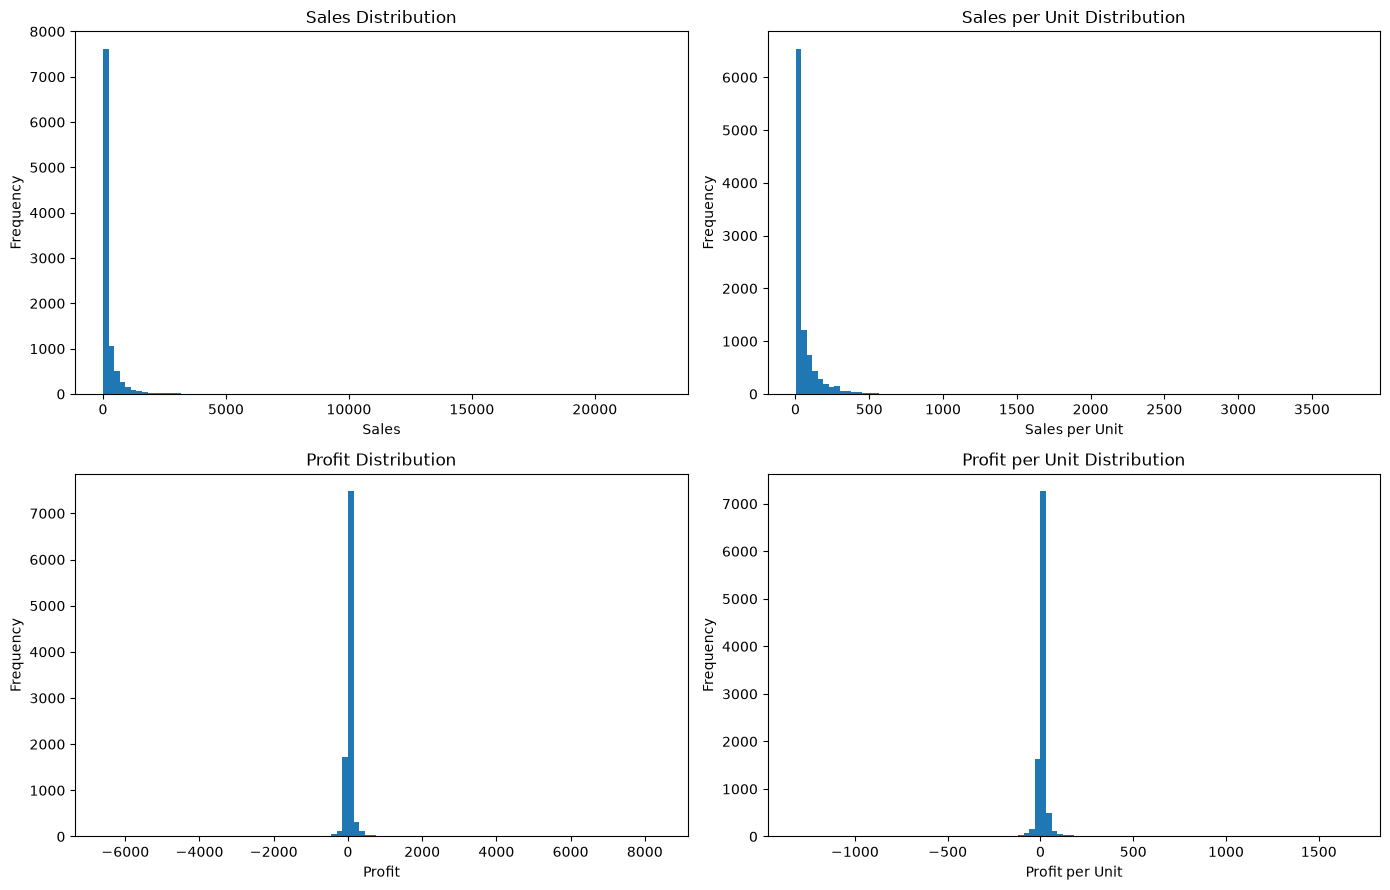

In [145]:
# 4.3 Numerical Distributions

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].hist(Orders["Sales"], bins=100)
axes[0, 0].set_title("Sales Distribution")
axes[0, 0].set_xlabel("Sales")
axes[0, 0].set_ylabel("Frequency")

axes[0, 1].hist(Orders["Sales per Unit"], bins=100)
axes[0, 1].set_title("Sales per Unit Distribution")
axes[0, 1].set_xlabel("Sales per Unit")
axes[0, 1].set_ylabel("Frequency")

axes[1, 0].hist(Orders["Profit"], bins=100)
axes[1, 0].set_title("Profit Distribution")
axes[1, 0].set_xlabel("Profit")
axes[1, 0].set_ylabel("Frequency")

axes[1, 1].hist(Orders["Profit per Unit"], bins=100)
axes[1, 1].set_title("Profit per Unit Distribution")
axes[1, 1].set_xlabel("Profit per Unit")
axes[1, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

Sales             → extreme right tail
Sales per Unit    → extreme right tail
Profit            → extreme values
Profit per Unit   → extreme values

## 4.4 Outlier Analysis

### 4.4.1 Sales Boxplot

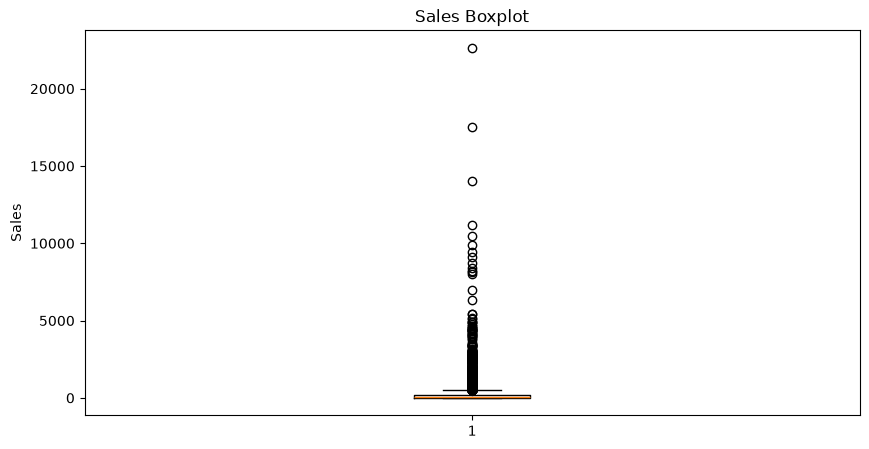

In [146]:
# 4.4 Outlier Analysis

# 4.4.1 Sales Boxplot

plt.figure(figsize=(10, 5))

plt.boxplot(Orders["Sales"])

plt.ylabel("Sales")
plt.title("Sales Boxplot")

plt.show()

In [147]:
# Calculate IQR for Sales

sales_q1 = Orders["Sales"].quantile(0.25)
sales_q3 = Orders["Sales"].quantile(0.75)

sales_iqr = sales_q3 - sales_q1

sales_lower_bound = sales_q1 - 1.5 * sales_iqr
sales_upper_bound = sales_q3 + 1.5 * sales_iqr

print("sales Q1:", sales_q1)
print("sales Q3:", sales_q3)
print("sales IQR:", sales_iqr)
print("sales Lower Bound:", sales_lower_bound)
print("sales Upper Bound:", sales_upper_bound)

# Calculate IQR for Sales per Unit

sales_per_unit_q1 = Orders["Sales per Unit"].quantile(0.25)
sales_per_unit_q3 = Orders["Sales per Unit"].quantile(0.75)

sales_per_unit_iqr = sales_per_unit_q3 - sales_per_unit_q1

sales_per_unit_lower_bound = sales_per_unit_q1 - 1.5 * sales_per_unit_iqr
sales_per_unit_upper_bound = sales_per_unit_q3 + 1.5 * sales_per_unit_iqr

print("\nsales per unit Q1:", sales_per_unit_q1)
print("sales per unit Q3:", sales_per_unit_q3)
print("sales per unit IQR:", sales_per_unit_iqr)
print("sales per unit Lower Bound:", sales_per_unit_lower_bound)
print("sales per unit Upper Bound:", sales_per_unit_upper_bound)

sales Q1: 17.28
sales Q3: 209.94
sales IQR: 192.66
sales Lower Bound: -271.71000000000004
sales Upper Bound: 498.93

sales per unit Q1: 5.47
sales per unit Q3: 63.94
sales per unit IQR: 58.47
sales per unit Lower Bound: -82.235
sales per unit Upper Bound: 151.64499999999998


In [148]:
# Count potential Sales outliers

sales_outliers = Orders[(Orders["Sales"] < sales_lower_bound) | (Orders["Sales"] > sales_upper_bound)]
sales_outliers_percent = (len(sales_outliers) / len(Orders)) * 100

print("Potential Sales outliers:", len(sales_outliers))
print("Percentage of Sales outliers:", sales_outliers_percent)

# Count potential Sales per Unit outliers

sales_per_unit_outliers = Orders[(Orders["Sales per Unit"] < sales_per_unit_lower_bound) | (Orders["Sales per Unit"] > sales_per_unit_upper_bound)]
sales_per_unit_outliers_percent = (len(sales_per_unit_outliers) / len(Orders)) * 100

print("Potential Sales per Unit outliers:", len(sales_per_unit_outliers))
print("Percentage of Sales per Unit outliers:", sales_per_unit_outliers_percent)

Potential Sales outliers: 1167
Percentage of Sales outliers: 11.677006203722232
Potential Sales per Unit outliers: 1054
Percentage of Sales per Unit outliers: 10.546327796678007


In [149]:
# Inspect potential Sales outliers

display(sales_outliers[["Row ID","Order ID","Product Name","Sales","Quantity","Sales per Unit","Discount","Profit"]]
        .sort_values("Sales", ascending=False).head(20))

,Row ID,Order ID,Product Name,Sales,Quantity,Sales per Unit,Discount,Profit
2697,2698,CA-2016-145317,Cisco TelePresence System EX90 Videoconferenci...,22638.480,6,3773.080,0.5,-1811.0784
6826,6827,CA-2018-118689,Canon imageCLASS 2200 Advanced Copier,17499.950,5,3499.990,0.0,8399.9760
8153,8154,CA-2019-140151,Canon imageCLASS 2200 Advanced Copier,13999.960,4,3499.990,0.0,6719.9808
2623,2624,CA-2019-127180,Canon imageCLASS 2200 Advanced Copier,11199.968,4,2799.992,0.2,3919.9888
4190,4191,CA-2019-166709,Canon imageCLASS 2200 Advanced Copier,10499.970,3,3499.990,0.0,5039.9856
9039,9040,CA-2018-117121,GBC Ibimaster 500 Manual ProClick Binding System,9892.740,13,760.980,0.0,4946.3700
4098,4099,CA-2016-116904,Ibico EPK-21 Electric Binding System,9449.950,5,1889.990,0.0,4630.4755
4277,4278,US-2018-107440,"3D Systems Cube Printer, 2nd Generation, Magenta",9099.930,7,1299.990,0.0,2365.9818
8488,8489,CA-2018-158841,HP Designjet T520 Inkjet Large Format Printer ...,8749.950,5,1749.990,0.0,2799.9840
6425,6426,CA-2018-143714,Canon imageCLASS 2200 Advanced Copier,8399.976,4,2099.994,0.4,1119.9968


### 4.4.2 Profit Boxplot

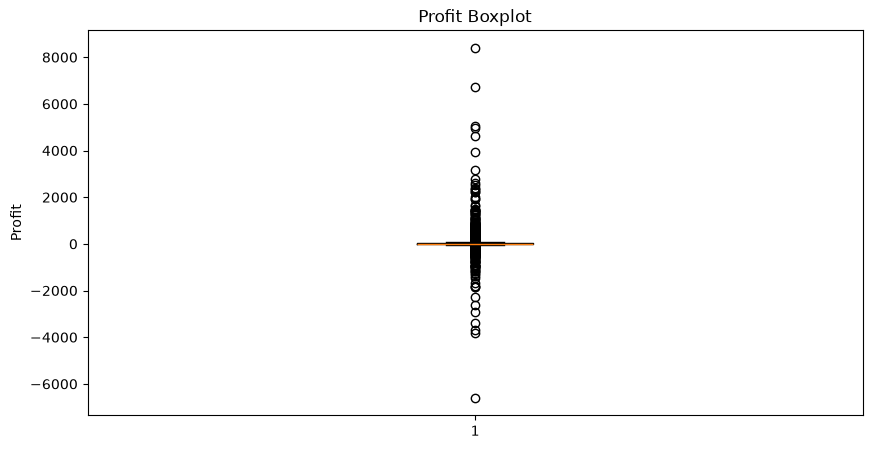

In [150]:
# 4.4.2 Profit Boxplot

plt.figure(figsize=(10, 5))

plt.boxplot(Orders["Profit"])

plt.ylabel("Profit")
plt.title("Profit Boxplot")

plt.show()

In [151]:
# Calculate IQR for Profit

profit_q1 = Orders["Profit"].quantile(0.25)
profit_q3 = Orders["Profit"].quantile(0.75)
profit_iqr = profit_q3 - profit_q1
profit_lower_bound = profit_q1 - 1.5 * profit_iqr
profit_upper_bound = profit_q3 + 1.5 * profit_iqr

print("Profit Q1:", profit_q1)
print("Profit Q3:", profit_q3)
print("Profit IQR:", profit_iqr)
print("Profit Lower Bound:", profit_lower_bound)
print("Profit Upper Bound:", profit_upper_bound)

# Calculate IQR for Profit per Unit

profit_per_unit_q1 = Orders["Profit per Unit"].quantile(0.25)
profit_per_unit_q3 = Orders["Profit per Unit"].quantile(0.75)
profit_per_unit_iqr = profit_per_unit_q3 - profit_per_unit_q1
profit_per_unit_lower_bound = profit_per_unit_q1 - 1.5 * profit_per_unit_iqr
profit_per_unit_upper_bound = profit_per_unit_q3 + 1.5 * profit_per_unit_iqr

print("\nProfit per Unit Q1:", profit_per_unit_q1)
print("Profit per Unit Q3:", profit_per_unit_q3)
print("Profit per Unit IQR:", profit_per_unit_iqr)
print("Profit per Unit Lower Bound:", profit_per_unit_lower_bound)
print("Profit per Unit Upper Bound:", profit_per_unit_upper_bound)

Profit Q1: 1.72875
Profit Q3: 29.363999999999997
Profit IQR: 27.635249999999996
Profit Lower Bound: -39.724124999999994
Profit Upper Bound: 70.81687499999998

Profit per Unit Q1: 0.7227999999999998
Profit per Unit Q3: 8.7032
Profit per Unit IQR: 7.980400000000001
Profit per Unit Lower Bound: -11.247800000000002
Profit per Unit Upper Bound: 20.6738


In [152]:
# Count potential Profit outliers

profit_outliers = Orders[(Orders["Profit"] < profit_lower_bound) | (Orders["Profit"] > profit_upper_bound)]

print("Potential Profit outliers:", len(profit_outliers))
print("Percentage of Profit outliers:", len(profit_outliers) / len(Orders) * 100)

# Count potential Profit per Unit outliers

profit_per_unit_outliers = Orders[(Orders["Profit per Unit"] < profit_per_unit_lower_bound) | (Orders["Profit per Unit"] > profit_per_unit_upper_bound)]

print("Potential Profit per Unit outliers:", len(profit_per_unit_outliers))
print("Percentage of Profit per Unit outliers:", len(profit_per_unit_outliers) / len(Orders) * 100)

Potential Profit outliers: 1881
Percentage of Profit outliers: 18.8212927756654
Potential Profit per Unit outliers: 1891
Percentage of Profit per Unit outliers: 18.92135281168701


In [153]:
# Inspect potential Profit outliers

display(profit_outliers[["Row ID","Order ID","Product Name","Sales","Quantity","Discount","Profit","Profit Margin","Profit per Unit"]]
        .sort_values("Profit").head(20))
display(profit_outliers[["Row ID","Order ID","Product Name","Sales","Quantity","Discount","Profit","Profit Margin","Profit per Unit"]]
        .sort_values("Profit", ascending=False).head(20))

,Row ID,Order ID,Product Name,Sales,Quantity,Discount,Profit,Profit Margin,Profit per Unit
7772,7773,CA-2018-108196,Cubify CubeX 3D Printer Double Head Print,4499.985,5,0.7,-6599.9780,-146.666667,-1319.9956
683,684,US-2019-168116,Cubify CubeX 3D Printer Triple Head Print,7999.980,4,0.5,-3839.9904,-48.000000,-959.9976
9774,9775,CA-2016-169019,GBC DocuBind P400 Electric Binding System,2177.584,8,0.8,-3701.8928,-170.000000,-462.7366
3011,3012,CA-2019-134845,Lexmark MX611dhe Monochrome Laser Printer,2549.985,5,0.7,-3399.9800,-133.333333,-679.9960
4991,4992,US-2019-122714,Ibico EPK-21 Electric Binding System,1889.990,5,0.8,-2929.4845,-155.000000,-585.8969
3151,3152,CA-2017-147830,Cubify CubeX 3D Printer Double Head Print,1799.994,2,0.7,-2639.9912,-146.666667,-1319.9956
5310,5311,CA-2019-131254,Fellowes PB500 Electric Punch Plastic Comb Bin...,1525.188,6,0.8,-2287.7820,-150.000000,-381.2970
9639,9640,CA-2017-116638,Chromcraft Bull-Nose Wood Oval Conference Tabl...,4297.644,13,0.4,-1862.3124,-43.333333,-143.2548
1199,1200,CA-2018-130946,GBC DocuBind P400 Electric Binding System,1088.792,4,0.8,-1850.9464,-170.000000,-462.7366
2697,2698,CA-2016-145317,Cisco TelePresence System EX90 Videoconferenci...,22638.480,6,0.5,-1811.0784,-8.000000,-301.8464


,Row ID,Order ID,Product Name,Sales,Quantity,Discount,Profit,Profit Margin,Profit per Unit
6826,6827,CA-2018-118689,Canon imageCLASS 2200 Advanced Copier,17499.950,5,0.0,8399.9760,48.00,1679.9952
8153,8154,CA-2019-140151,Canon imageCLASS 2200 Advanced Copier,13999.960,4,0.0,6719.9808,48.00,1679.9952
4190,4191,CA-2019-166709,Canon imageCLASS 2200 Advanced Copier,10499.970,3,0.0,5039.9856,48.00,1679.9952
9039,9040,CA-2018-117121,GBC Ibimaster 500 Manual ProClick Binding System,9892.740,13,0.0,4946.3700,50.00,380.4900
4098,4099,CA-2016-116904,Ibico EPK-21 Electric Binding System,9449.950,5,0.0,4630.4755,49.00,926.0951
2623,2624,CA-2019-127180,Canon imageCLASS 2200 Advanced Copier,11199.968,4,0.2,3919.9888,35.00,979.9972
509,510,CA-2017-145352,Fellowes PB500 Electric Punch Plastic Comb Bin...,6354.950,5,0.0,3177.4750,50.00,635.4950
8488,8489,CA-2018-158841,HP Designjet T520 Inkjet Large Format Printer ...,8749.950,5,0.0,2799.9840,32.00,559.9968
7666,7667,US-2018-140158,Hewlett Packard LaserJet 3310 Copier,5399.910,9,0.0,2591.9568,48.00,287.9952
6520,6521,CA-2019-138289,GBC DocuBind P400 Electric Binding System,5443.960,4,0.0,2504.2216,46.00,626.0554


### 4.4.3 Profit Margin Distribution

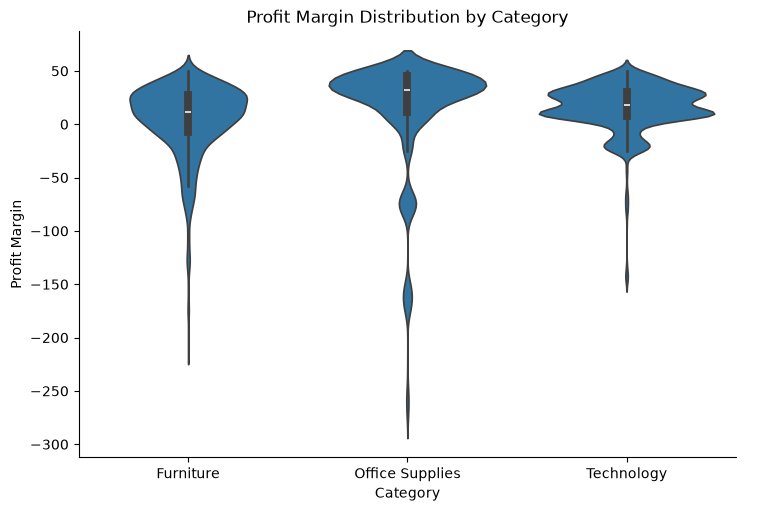

In [154]:
# 4.4.3 Profit Margin Distribution by Category

sns.catplot(data=Orders, x="Category", y="Profit Margin", kind="violin", aspect=1.5)

plt.title("Profit Margin Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin")

plt.show()

In [155]:
# Calculate IQR for Profit Margin

pm_q1 = Orders["Profit Margin"].quantile(0.25)
pm_q3 = Orders["Profit Margin"].quantile(0.75)

pm_iqr = pm_q3 - pm_q1

pm_lower_bound = pm_q1 - 1.5 * pm_iqr
pm_upper_bound = pm_q3 + 1.5 * pm_iqr

print("Profit Margin Q1:", pm_q1)
print("Profit Margin Q3:", pm_q3)
print("Profit Margin IQR:", pm_iqr)
print("Profit Margin Lower Bound:", pm_lower_bound)
print("Profit Margin Upper Bound:", pm_upper_bound)

Profit Margin Q1: 7.499999999999994
Profit Margin Q3: 36.25
Profit Margin IQR: 28.750000000000007
Profit Margin Lower Bound: -35.62500000000002
Profit Margin Upper Bound: 79.37500000000001


In [156]:
# Count potential Profit Margin outliers

profit_margin_outliers = Orders[(Orders["Profit Margin"] < pm_lower_bound) |(Orders["Profit Margin"] > pm_upper_bound)]

print("Potential Profit Margin outliers:", len(profit_margin_outliers))
print("Percentage of Profit Margin outliers:", len(profit_margin_outliers) / len(Orders) * 100)

Potential Profit Margin outliers: 952
Percentage of Profit Margin outliers: 9.525715429257554


In [157]:
# Inspect potential Profit Margin outliers

display(profit_margin_outliers[["Row ID", "Order ID", "Product Name", "Sales", "Quantity", "Discount", "Profit", "Profit Margin", "Profit per Unit"]]
        .sort_values("Profit Margin").head(20))

,Row ID,Order ID,Product Name,Sales,Quantity,Discount,Profit,Profit Margin,Profit per Unit
676,677,US-2019-119438,Hoover Portapower Portable Vacuum,2.688,3,0.8,-7.3920,-275.0,-2.4640
8766,8767,CA-2017-107083,Kensington 6 Outlet SmartSocket Surge Protector,24.588,3,0.8,-67.6170,-275.0,-22.5390
9164,9165,CA-2017-164007,Hoover Shoulder Vac Commercial Portable Vacuum,143.128,2,0.8,-393.6020,-275.0,-196.8010
261,262,US-2019-155299,Eureka Disposable Bags for Sanitaire Vibra Gro...,1.624,2,0.8,-4.4660,-275.0,-2.2330
6561,6562,CA-2019-144680,Fellowes 8 Outlet Superior Workstation Surge P...,33.620,5,0.8,-90.7740,-270.0,-18.1548
5414,5415,US-2019-125647,Euro Pro Shark Stick Mini Vacuum,73.176,6,0.8,-197.5752,-270.0,-32.9292
9086,9087,CA-2018-143406,Hoover Commercial Lightweight Upright Vacuum w...,93.032,2,0.8,-251.1864,-270.0,-125.5932
8916,8917,US-2018-144057,Euro Pro Shark Stick Mini Vacuum,48.784,4,0.8,-131.7168,-270.0,-32.9292
6989,6990,CA-2019-165099,Hoover Commercial Lightweight Upright Vacuum,1.392,2,0.8,-3.7584,-270.0,-1.8792
4980,4981,US-2018-131114,Belkin 6 Outlet Metallic Surge Strip,4.356,2,0.8,-11.7612,-270.0,-5.8806


In [158]:
Orders.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping Duration', 'Profit Margin', 'Profit per Unit',
       'Sales per Unit', 'Sales Performance Category', 'Order Year',
       'Order Quarter', 'Order Month', 'Order Day', 'Ship Year',
       'Ship Quarter', 'Ship Month', 'Ship Day'],
      dtype='str')

## 4.5 Categorical Performance Analysis

### 4.5.1 Sales Performance Across Key Dimensions


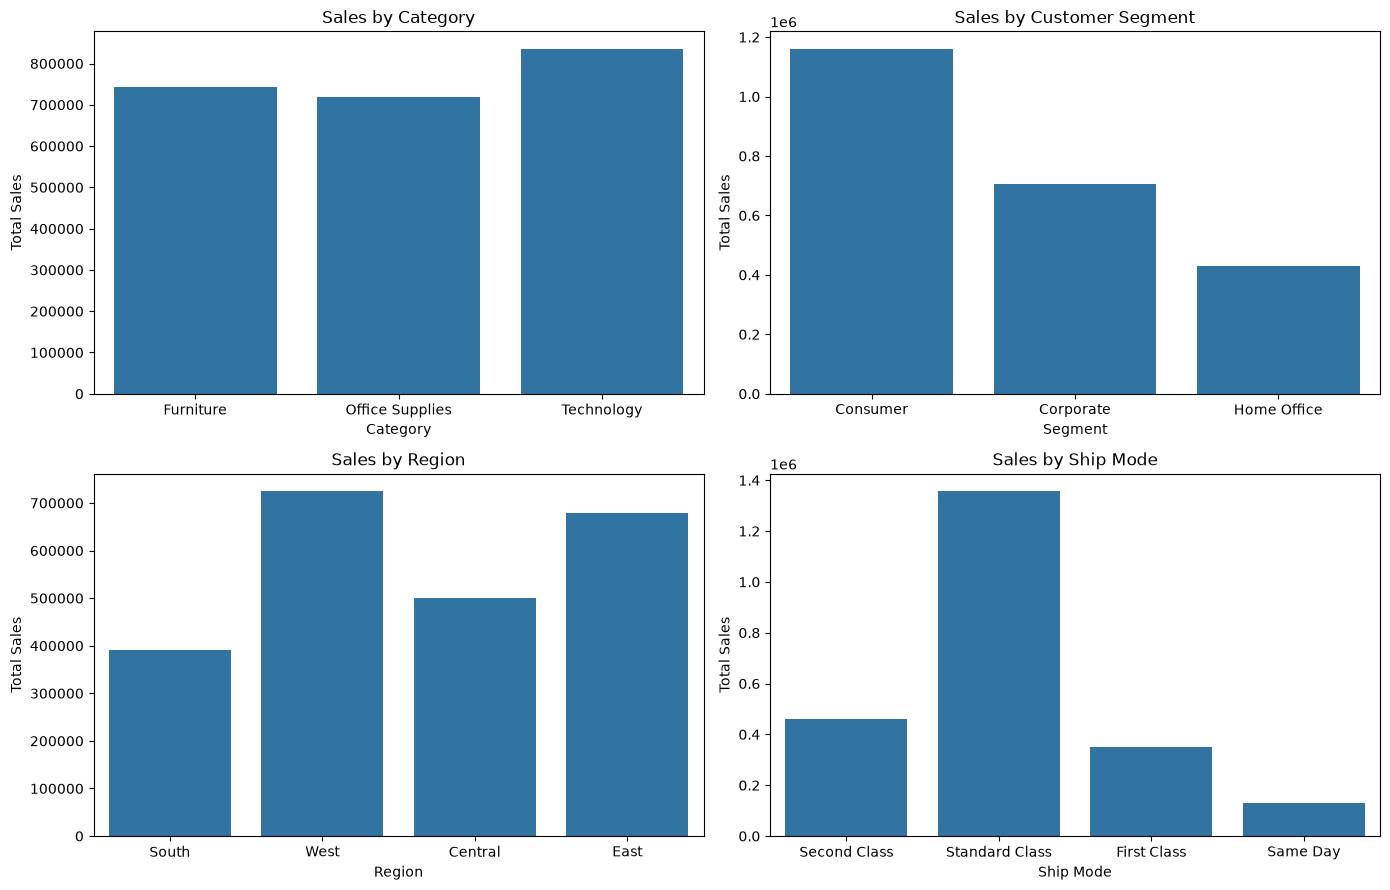

In [159]:
# 4.5 Categorical Performance Analysis
# 4.5.1 Sales Performance Across Key Dimensions

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.barplot(x="Category", y="Sales", data=Orders, estimator=sum, errorbar=None, ax=axes[0, 0])
axes[0, 0].set_title("Sales by Category")
axes[0, 0].set_xlabel("Category")
axes[0, 0].set_ylabel("Total Sales")

sns.barplot(x="Segment", y="Sales", data=Orders, estimator=sum, errorbar=None, ax=axes[0, 1])
axes[0, 1].set_title("Sales by Customer Segment")
axes[0, 1].set_xlabel("Segment")
axes[0, 1].set_ylabel("Total Sales")

sns.barplot(x="Region", y="Sales", data=Orders, estimator=sum, errorbar=None, ax=axes[1, 0])
axes[1, 0].set_title("Sales by Region")
axes[1, 0].set_xlabel("Region")
axes[1, 0].set_ylabel("Total Sales")

sns.barplot(x="Ship Mode", y="Sales", data=Orders, estimator=sum, errorbar=None, ax=axes[1, 1])
axes[1, 1].set_title("Sales by Ship Mode")
axes[1, 1].set_xlabel("Ship Mode")
axes[1, 1].set_ylabel("Total Sales")

plt.tight_layout()
plt.show()

### 4.5.2 Profit Performance Across Key Dimensions

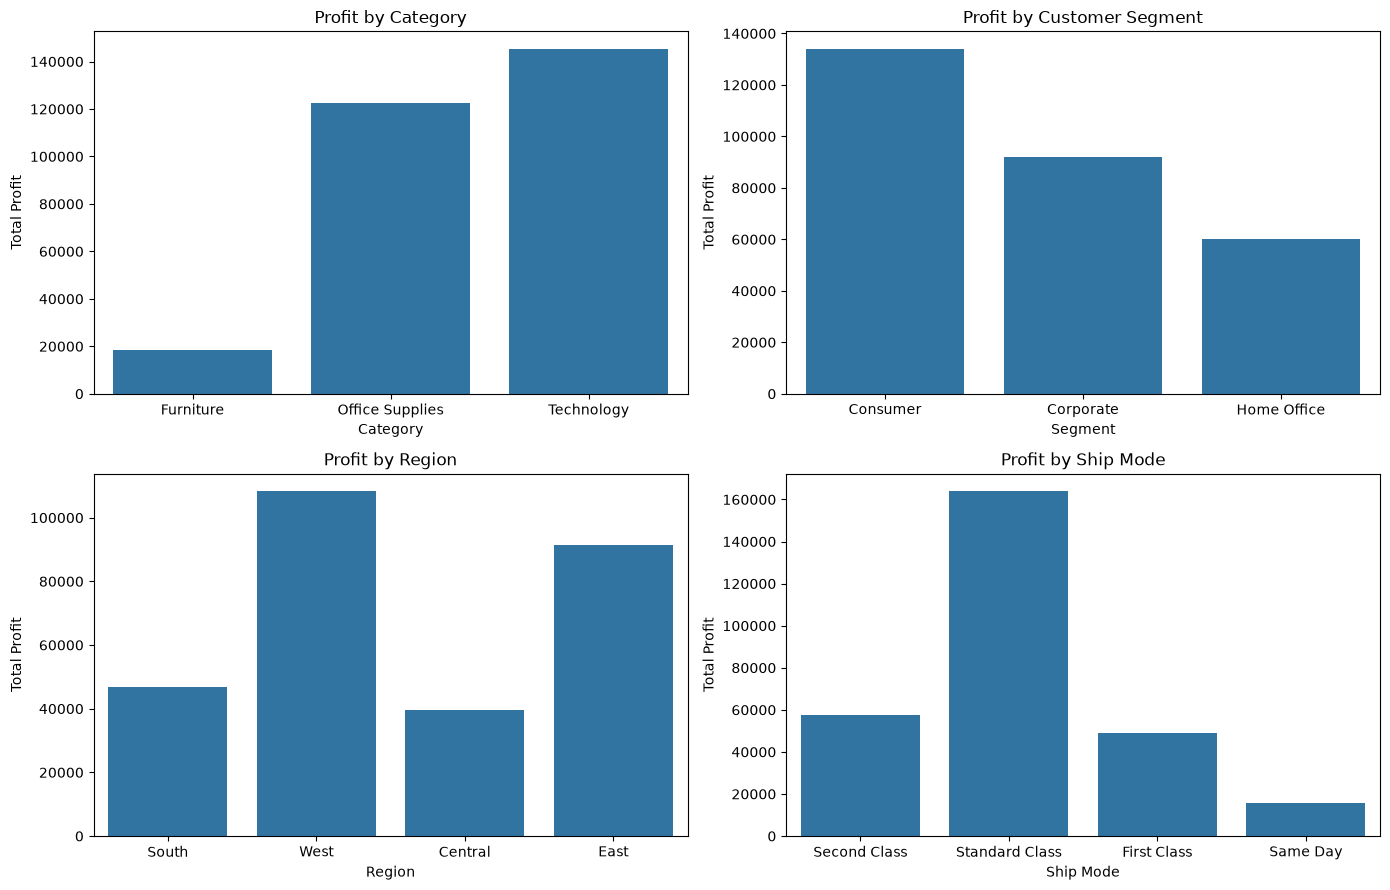

In [160]:
# 4.5.2 Profit Performance Across Key Dimensions

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.barplot(x="Category", y="Profit", data=Orders, estimator=sum, errorbar=None, ax=axes[0, 0])
axes[0, 0].set_title("Profit by Category")
axes[0, 0].set_xlabel("Category")
axes[0, 0].set_ylabel("Total Profit")

sns.barplot(x="Segment", y="Profit", data=Orders, estimator=sum, errorbar=None, ax=axes[0, 1])
axes[0, 1].set_title("Profit by Customer Segment")
axes[0, 1].set_xlabel("Segment")
axes[0, 1].set_ylabel("Total Profit")

sns.barplot(x="Region", y="Profit", data=Orders, estimator=sum, errorbar=None, ax=axes[1, 0])
axes[1, 0].set_title("Profit by Region")
axes[1, 0].set_xlabel("Region")
axes[1, 0].set_ylabel("Total Profit")

sns.barplot(x="Ship Mode", y="Profit", data=Orders, estimator=sum, errorbar=None, ax=axes[1, 1])
axes[1, 1].set_title("Profit by Ship Mode")
axes[1, 1].set_xlabel("Ship Mode")
axes[1, 1].set_ylabel("Total Profit")

plt.tight_layout()
plt.show()

### 4.5.3 Categorical Performance Summary

In [161]:
# 4.5 Categorical Performance Analysis

category_performance = Orders.groupby("Category").agg(Total_Sales=("Sales", "sum"), Total_Profit=("Profit", "sum"))
category_performance["Profit Margin"] = (category_performance["Total_Profit"] / category_performance["Total_Sales"]) * 100

Region_performance = Orders.groupby("Region").agg(Total_Sales=("Sales", "sum"), Total_Profit=("Profit", "sum"))
Region_performance["Profit Margin"] = (Region_performance["Total_Profit"] / Region_performance["Total_Sales"]) * 100

Segment_performance = Orders.groupby("Segment").agg(Total_Sales=("Sales", "sum"), Total_Profit=("Profit", "sum"))
Segment_performance["Profit Margin"] = (Segment_performance["Total_Profit"] / Segment_performance["Total_Sales"]) * 100

Ship_Mode_performance = Orders.groupby("Ship Mode").agg(Total_Sales=("Sales", "sum"), Total_Profit=("Profit", "sum"))
Ship_Mode_performance["Profit Margin"] = (Ship_Mode_performance["Total_Profit"] / Ship_Mode_performance["Total_Sales"]) * 100

display(category_performance)
display(Region_performance)
display(Segment_performance)
display(Ship_Mode_performance)

,Total_Sales,Total_Profit,Profit Margin
Category,,,
Furniture,741999.7953,18451.2728,2.486695
Office Supplies,719047.0320,122490.8008,17.035158
Technology,836154.0330,145454.9481,17.395712


,Total_Sales,Total_Profit,Profit Margin
Region,,,
Central,501239.8908,39706.3625,7.921629
East,678781.2400,91522.7800,13.483399
South,391721.9050,46749.4303,11.934342
West,725457.8245,108418.4489,14.944831


,Total_Sales,Total_Profit,Profit Margin
Segment,,,
Consumer,1.161401e+06,134119.2092,11.548050
Corporate,7.061464e+05,91979.1340,13.025506
Home Office,4.296531e+05,60298.6785,14.034269


,Total_Sales,Total_Profit,Profit Margin
Ship Mode,,,
First Class,3.514284e+05,48969.8399,13.934513
Same Day,1.283631e+05,15891.7589,12.380315
Second Class,4.591936e+05,57446.6354,12.510331
Standard Class,1.358216e+06,164088.7875,12.081202


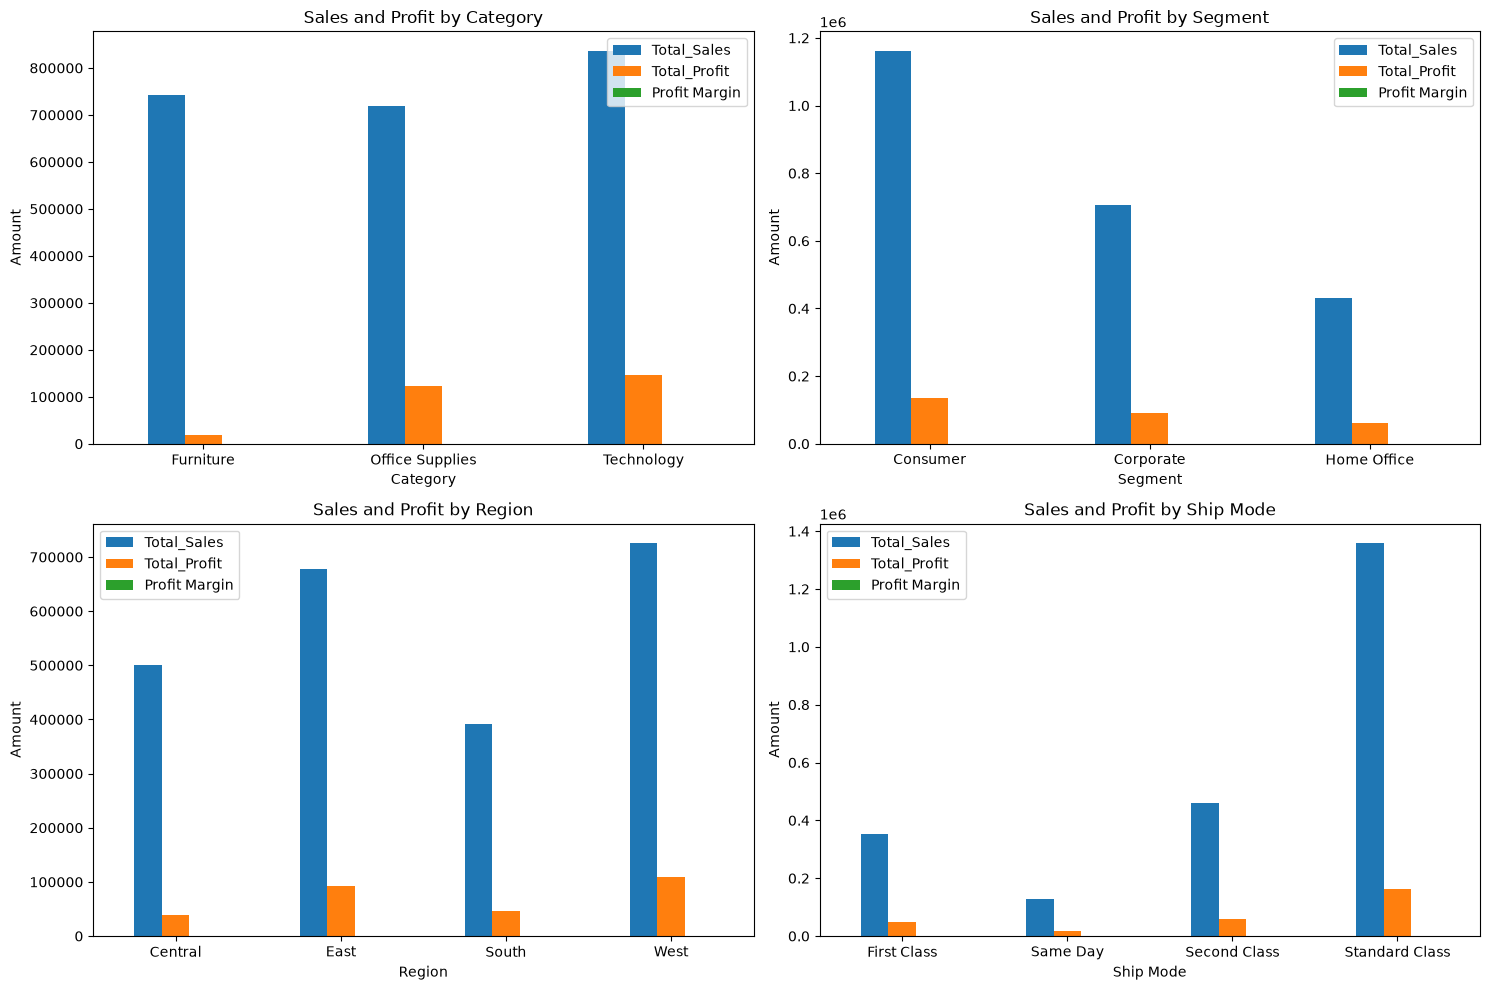

In [162]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Category
category_performance.plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set_title("Sales and Profit by Category")
axes[0, 0].set_xlabel("Category")
axes[0, 0].set_ylabel("Amount")
axes[0, 0].tick_params(axis="x", rotation=0)

# Segment
Segment_performance.plot(kind="bar", ax=axes[0, 1])
axes[0, 1].set_title("Sales and Profit by Segment")
axes[0, 1].set_xlabel("Segment")
axes[0, 1].set_ylabel("Amount")
axes[0, 1].tick_params(axis="x", rotation=0)

# Region
Region_performance.plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("Sales and Profit by Region")
axes[1, 0].set_xlabel("Region")
axes[1, 0].set_ylabel("Amount")
axes[1, 0].tick_params(axis="x", rotation=0)

# Ship Mode
Ship_Mode_performance.plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("Sales and Profit by Ship Mode")
axes[1, 1].set_xlabel("Ship Mode")
axes[1, 1].set_ylabel("Amount")
axes[1, 1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 4.6 Discount and Profitability Analysis

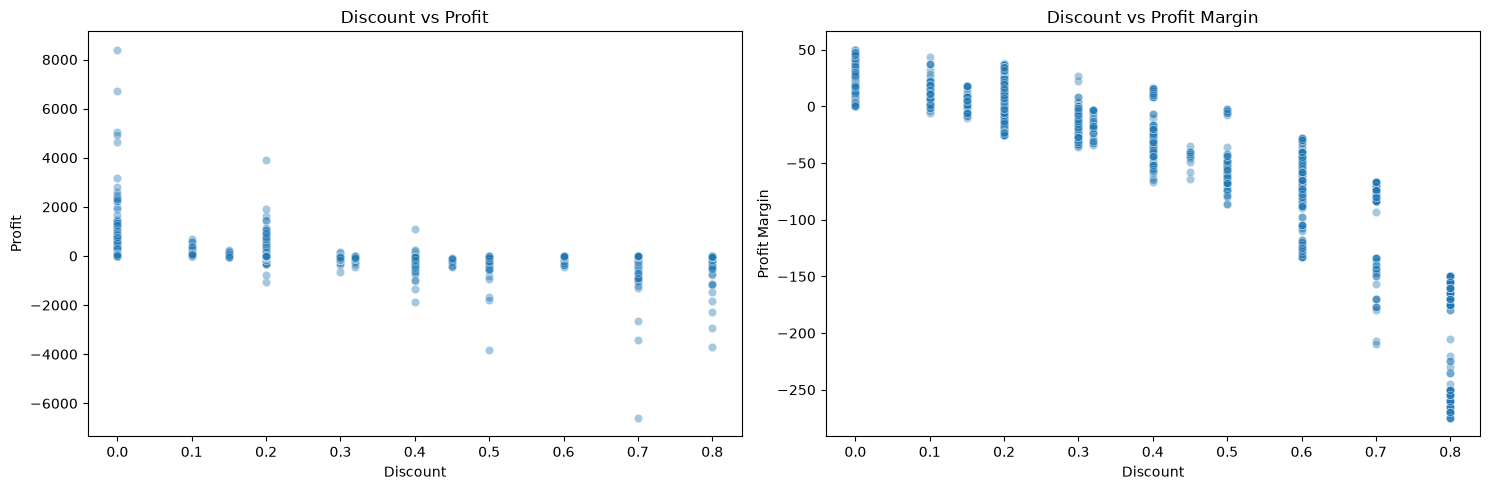

In [163]:
# 4.6 Discount and Profitability Analysis

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(data=Orders, x="Discount", y="Profit", alpha=0.4, ax=axes[0])
axes[0].set_xlabel("Discount")
axes[0].set_ylabel("Profit")
axes[0].set_title("Discount vs Profit")

sns.scatterplot(data=Orders, x="Discount", y="Profit Margin", alpha=0.4, ax=axes[1])
axes[1].set_xlabel("Discount")
axes[1].set_ylabel("Profit Margin")
axes[1].set_title("Discount vs Profit Margin")

plt.tight_layout()
plt.show()

### 4.6.1 Discount and Profit Correlation

In [164]:
# Calculate correlation between Discount and Profit

correlation = Orders["Discount"].corr(Orders["Profit Margin"])
print(f"Correlation between Discount and Profit Matgin: {correlation}")

correlation2 = Orders["Discount"].corr(Orders["Profit"])
print(f"Correlation between Discount and Profit: {correlation2}")

Correlation between Discount and Profit Matgin: -0.8644522856000377
Correlation between Discount and Profit: -0.21948745637176836


### 4.6.2 Correlation Matrix

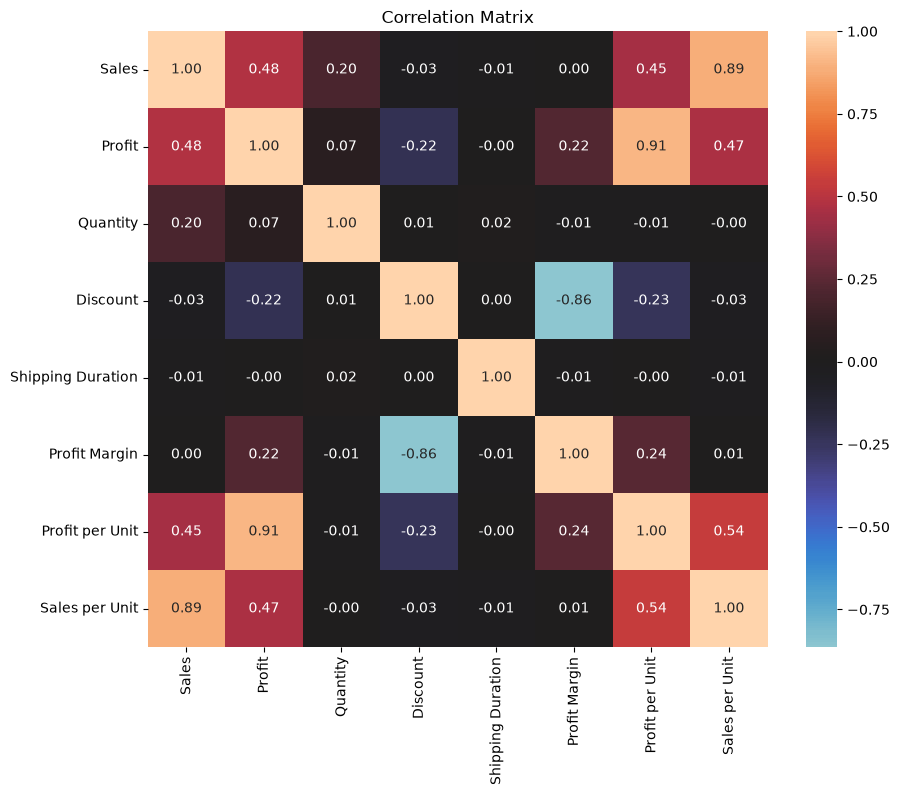

In [165]:
corr_matrix = Orders[["Sales", "Profit", "Quantity", "Discount", "Shipping Duration", "Profit Margin", "Profit per Unit", "Sales per Unit"]].corr()

# Visualize correlations between numeric variables

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",

    center=0
)

plt.title("Correlation Matrix")
plt.show()

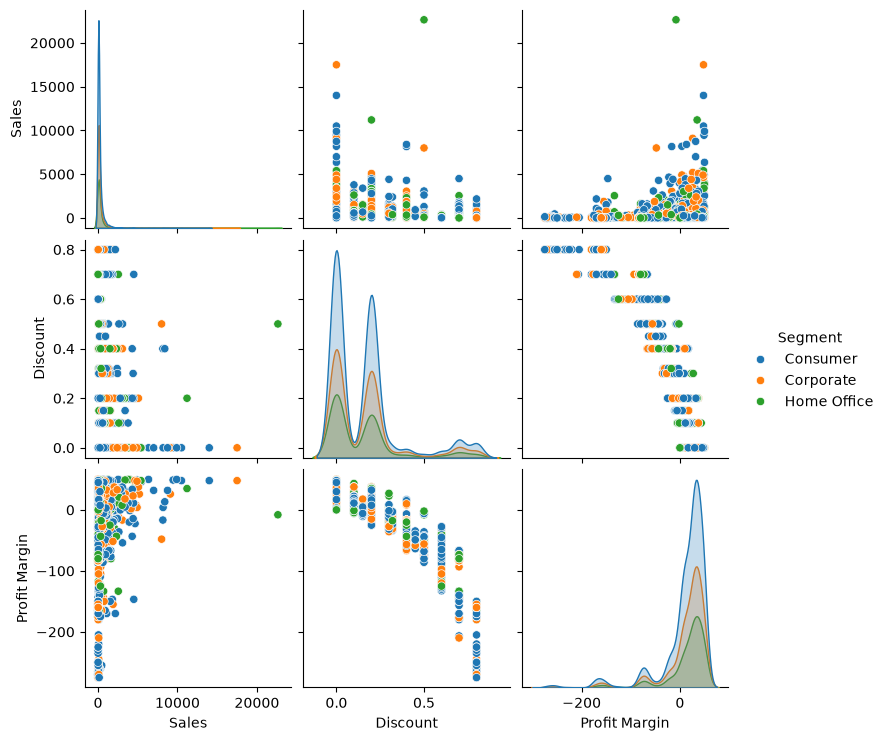

In [166]:
sns.pairplot(Orders[[ "Sales", "Discount", "Profit Margin", "Segment"]], hue="Segment")

plt.show()

## 4.7 Quantity vs Sales

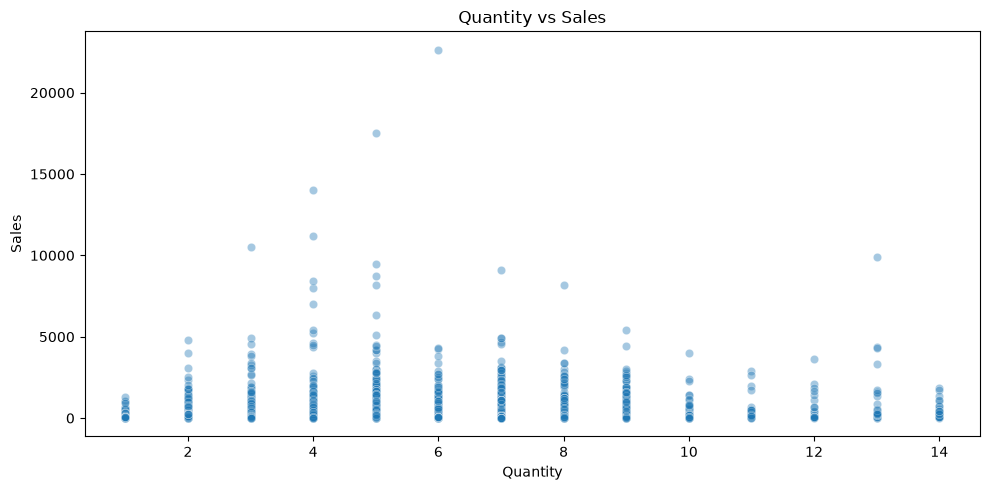

In [167]:
# 4.7 Quantity vs Sales

plt.figure(figsize=(10, 5))

sns.scatterplot(data=Orders, x="Quantity", y="Sales", alpha=0.4)

plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.title("Quantity vs Sales")

plt.tight_layout()
plt.show()

### 4.7.1 Quantity and Sales Correlation

In [168]:
# Calculate correlation between Quantity and Sales

correlation3 = Orders["Quantity"].corr(Orders["Sales"])
print(f"Correlation between Quantity and Sales: {correlation3}")

Correlation between Quantity and Sales: 0.2007947713738977


In [169]:
Orders.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping Duration', 'Profit Margin', 'Profit per Unit',
       'Sales per Unit', 'Sales Performance Category', 'Order Year',
       'Order Quarter', 'Order Month', 'Order Day', 'Ship Year',
       'Ship Quarter', 'Ship Month', 'Ship Day'],
      dtype='str')

## 4.8 Sales and Profit Trends

In [170]:
# 4.8.1 Year-over-Year Sales and Profit

yearly = (Orders.groupby("Order Year")[["Sales", "Profit"]].sum())
display(yearly)

,Sales,Profit
Order Year,,
2016,484247.4981,49543.9741
2017,470532.5090,61618.6037
2018,609205.5980,81795.1743
2019,733215.2552,93439.2696


### 4.8.1 Year-over-Year Sales and Profit

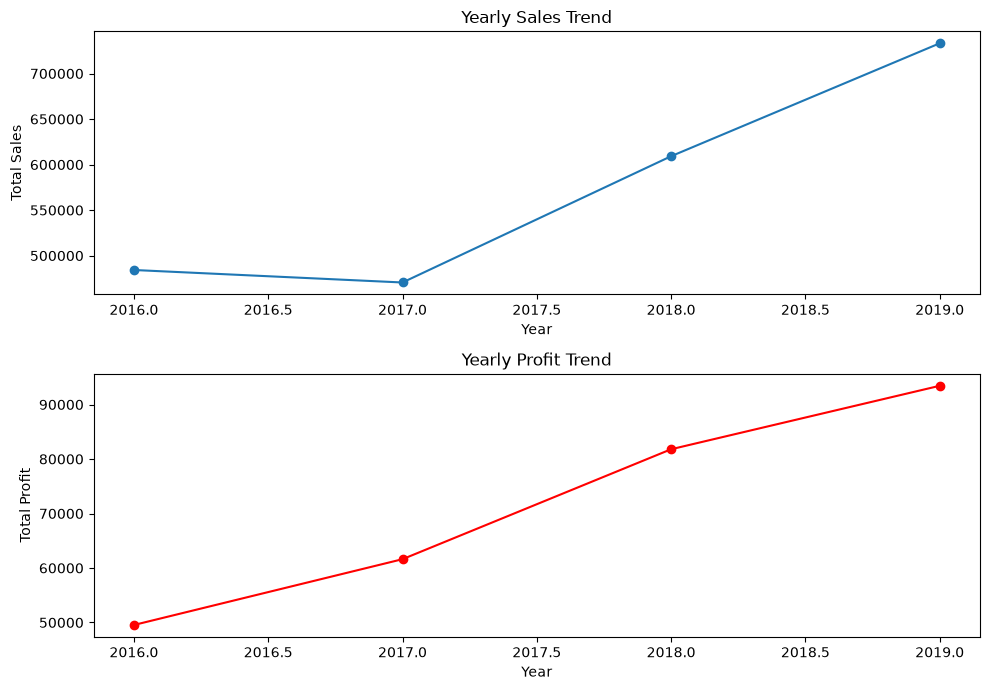

In [171]:
# Yearly Sales and Profit Trends
sales = Orders.groupby("Order Year")["Sales"].sum()
Profit = Orders.groupby("Order Year")["Profit"].sum()

fig, axes = plt.subplots(2, 1, figsize=(10, 7))

# Yearly Sales
axes[0].plot(sales.index, sales.values, marker="o")
axes[0].set_title("Yearly Sales Trend")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Total Sales")

# Yearly Profit
axes[1].plot(Profit.index, Profit.values, marker="o", color="red")
axes[1].set_title("Yearly Profit Trend")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Total Profit")

plt.tight_layout()
plt.show()


### 4.8.2 Monthly Sales and Profit Trends

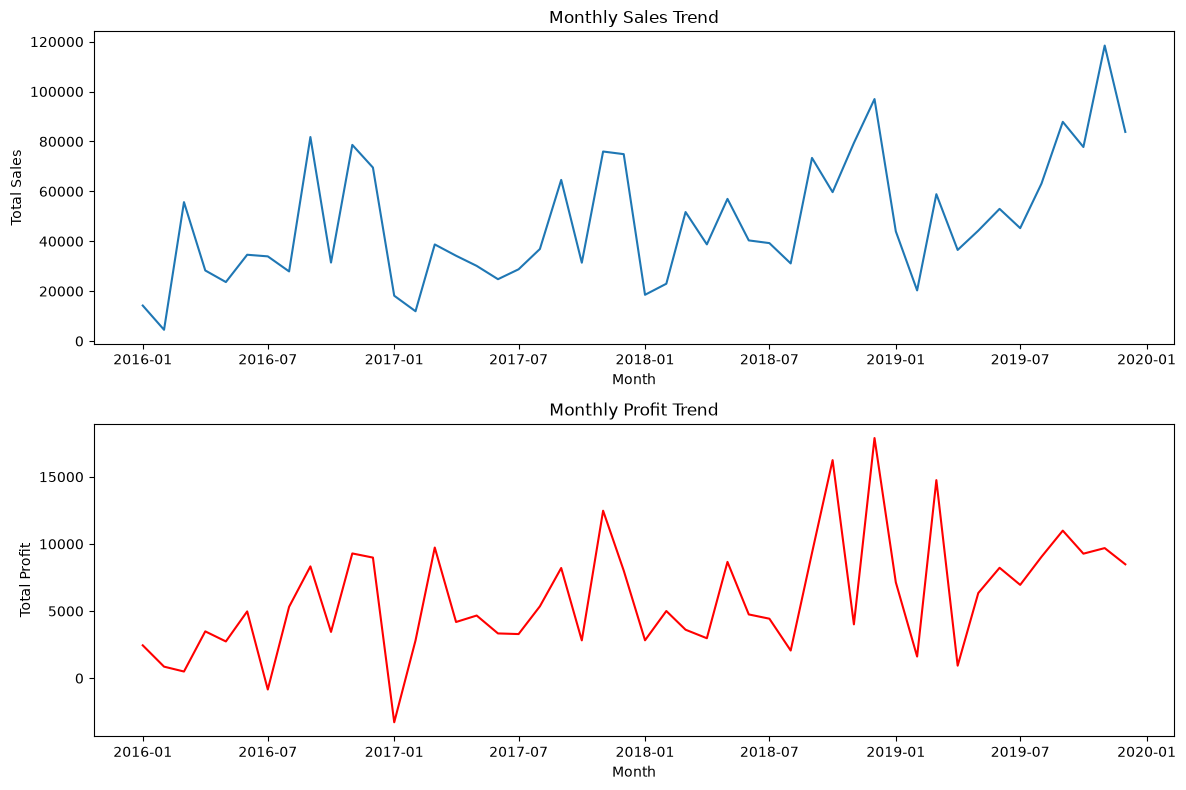

In [172]:
# 4.8.2 Monthly Sales and Profit Trends

monthly = (Orders.groupby(Orders["Order Date"].dt.to_period("M"))[["Sales", "Profit"]].sum())

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Monthly Sales Trend
axes[0].plot(monthly.index.to_timestamp(),monthly["Sales"])

axes[0].set_title("Monthly Sales Trend")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Total Sales")

# Monthly Profit Trend
axes[1].plot(monthly.index.to_timestamp(), monthly["Profit"], color="red")

axes[1].set_title("Monthly Profit Trend")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Total Profit")

plt.tight_layout()
plt.show()

### 4.8.3 Monthly Sales Seasonality

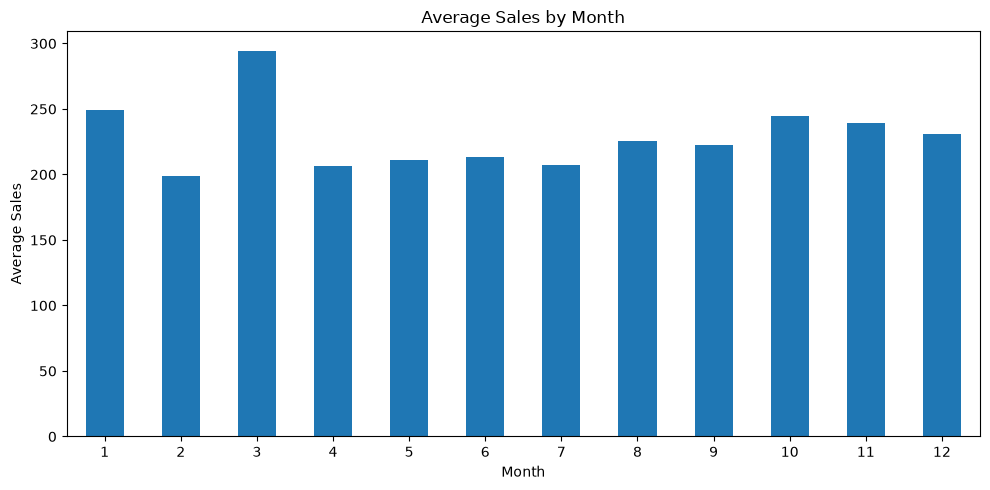

In [173]:
# 4.8.3 Monthly Sales Seasonality

monthly_seasonality = (Orders.groupby("Order Month")["Sales"].mean())

# Visualize monthly sales seasonality

plt.figure(figsize=(10, 5))

monthly_seasonality.plot(kind="bar")

plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.title("Average Sales by Month")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 4.8.4 Monthly Trend Visualization

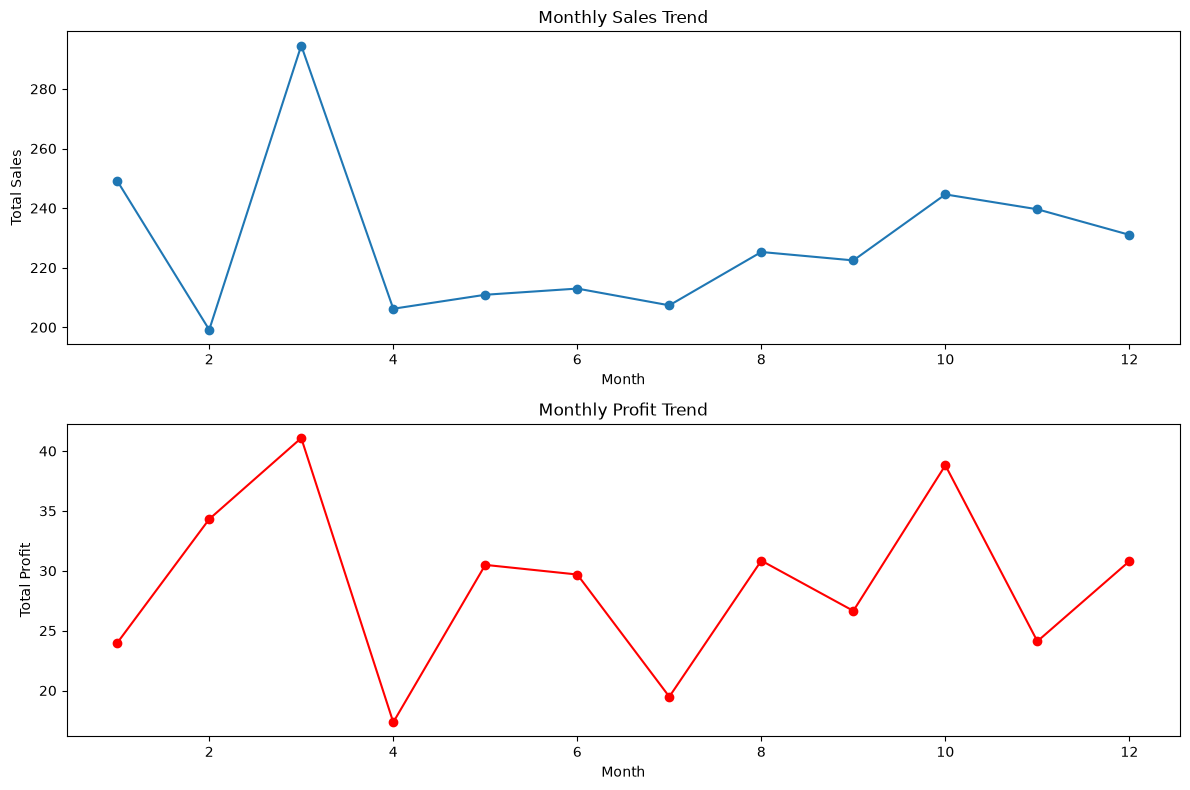

In [174]:
# 4.8.4 Monthly Sales and Profit Trends

monthly_sales = Orders.groupby("Order Month")["Sales"].mean()
monthly_profit = Orders.groupby("Order Month")["Profit"].mean()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Monthly Sales Trend
axes[0].plot(monthly_sales.index, monthly_sales.values, marker="o")

axes[0].set_title("Monthly Sales Trend")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Total Sales")

# Monthly Profit Trend
axes[1].plot(monthly_profit.index, monthly_profit.values, marker="o", color="red")

axes[1].set_title("Monthly Profit Trend")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Total Profit")

plt.tight_layout()
plt.show()

## 4.9 Customer Performance Analysis

In [175]:
# 4.9.1 Customer Performance

customer_performance = (Orders.groupby(["Customer ID", "Customer Name"]).agg(Total_Sales=("Sales", "sum"), Total_Profit=("Profit", "sum"))
                        .sort_values("Total_Sales", ascending=False))

# 4.9.2 Customer Profitability
customer_profitability = (Orders.groupby(["Customer ID", "Customer Name"]).agg(Total_Sales=("Sales", "sum"),Total_Profit=("Profit", "sum"))
                        .sort_values("Total_Profit", ascending=False))

display(customer_profitability.head(10))
display(customer_performance.head(10))

,,Total_Sales,Total_Profit
Customer ID,Customer Name,,
TC-20980,Tamara Chand,19052.218,8981.3239
RB-19360,Raymond Buch,15117.339,6976.0959
SC-20095,Sanjit Chand,14142.334,5757.4119
HL-15040,Hunter Lopez,12873.298,5622.4292
AB-10105,Adrian Barton,14473.571,5444.8055
TA-21385,Tom Ashbrook,14595.620,4703.7883
CM-12385,Christopher Martinez,8954.020,3899.8904
KD-16495,Keith Dawkins,8181.256,3038.6254
AR-10540,Andy Reiter,6608.448,2884.6208


,,Total_Sales,Total_Profit
Customer ID,Customer Name,,
SM-20320,Sean Miller,25043.050,-1980.7393
TC-20980,Tamara Chand,19052.218,8981.3239
RB-19360,Raymond Buch,15117.339,6976.0959
TA-21385,Tom Ashbrook,14595.620,4703.7883
AB-10105,Adrian Barton,14473.571,5444.8055
KL-16645,Ken Lonsdale,14175.229,806.8550
SC-20095,Sanjit Chand,14142.334,5757.4119
HL-15040,Hunter Lopez,12873.298,5622.4292
SE-20110,Sanjit Engle,12209.438,2650.6769


### 4.9.1 Top Customers by Sales and Profit

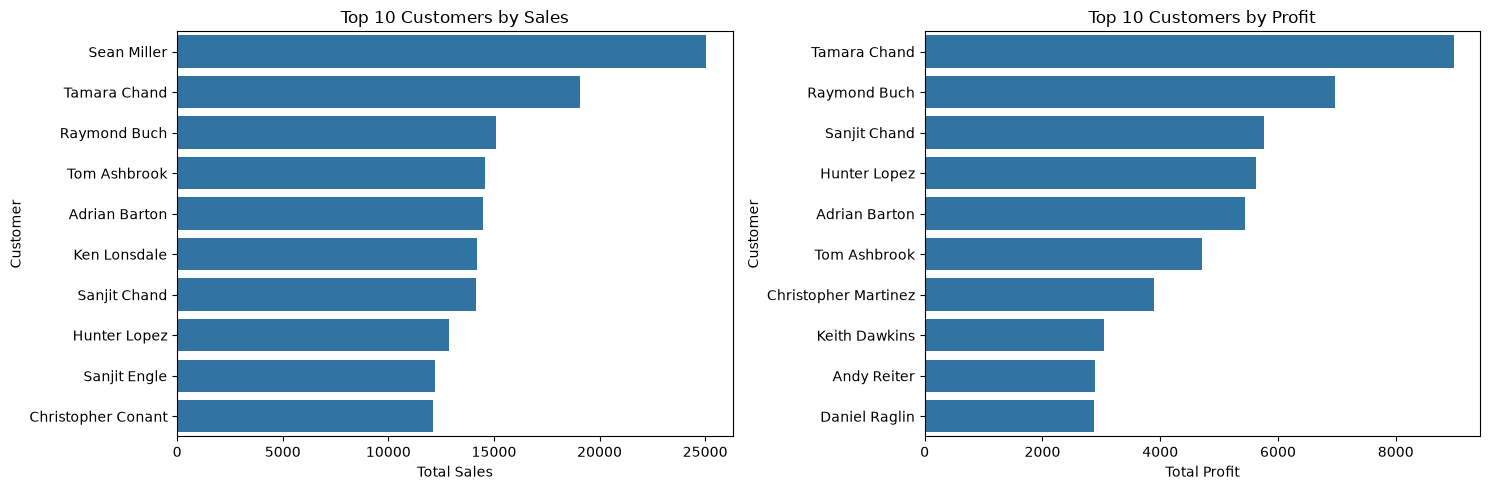

In [176]:
# Top 10 customers by total sales and profit
top_customers = customer_performance.head(10)
top_profit_customers = customer_profitability.head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Top 10 Customers by Sales
sns.barplot(x=top_customers["Total_Sales"], y=top_customers.index.get_level_values("Customer Name"), errorbar=None, ax=axes[0])

axes[0].set_xlabel("Total Sales")
axes[0].set_ylabel("Customer")
axes[0].set_title("Top 10 Customers by Sales")


# Top 10 Customers by Profit
sns.barplot(x=top_profit_customers["Total_Profit"], y=top_profit_customers.index.get_level_values("Customer Name"), errorbar=None, ax=axes[1])

axes[1].set_xlabel("Total Profit")
axes[1].set_ylabel("Customer")
axes[1].set_title("Top 10 Customers by Profit")

plt.tight_layout()
plt.show()

## 4.10 People Analysis

In [177]:
# 4.10.1 Merge People with Orders

orders_people = pd.merge(Orders, People, on="Region", how="left")

display(orders_people[["Person", "Region", "Sales", "Profit"]].head())

,Person,Region,Sales,Profit
0,Cassandra Brandow,South,261.9600,41.9136
1,Cassandra Brandow,South,731.9400,219.5820
2,Anna Andreadi,West,14.6200,6.8714
3,Cassandra Brandow,South,957.5775,-383.0310
4,Cassandra Brandow,South,22.3680,2.5164


### 4.10.1 Sales and Profit by Person

In [178]:
# 4.10.2 Sales and Profit by Person

person_performance = (orders_people.groupby("Person").agg(Total_Sales=("Sales", "sum"), Total_Profit=("Profit", "sum"))
                      .sort_values("Total_Sales", ascending=False))

display(person_performance)

,Total_Sales,Total_Profit
Person,,
Anna Andreadi,725457.8245,108418.4489
Chuck Magee,678781.2400,91522.7800
Kelly Williams,501239.8908,39706.3625
Cassandra Brandow,391721.9050,46749.4303


### 4.10.2 People Performance Visualization

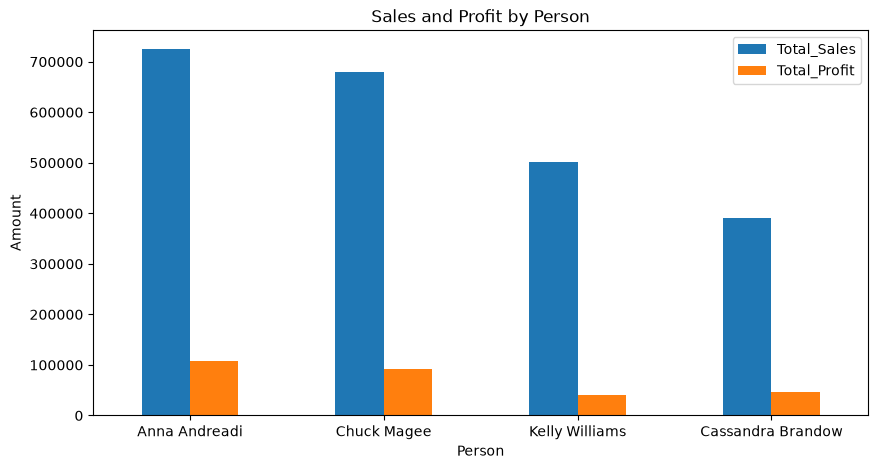

In [179]:
# Visualize sales and profit by person

person_performance.plot(kind="bar", figsize=(10, 5))

plt.xlabel("Person")
plt.ylabel("Amount")
plt.title("Sales and Profit by Person")
plt.xticks(rotation=0)
plt.show()

## 4.11 Returns Analysis

In [180]:
# 4.11.1 Merge Returns with Orders

orders_returns = pd.merge(Orders, Returns, on="Order ID", how="left")
orders_returns["Returned"] = (orders_returns["Returned"].fillna("No"))

display(orders_returns[["Order ID", "Returned", "Sales", "Profit"]].head())

,Order ID,Returned,Sales,Profit
0,CA-2018-152156,No,261.9600,41.9136
1,CA-2018-152156,No,731.9400,219.5820
2,CA-2018-138688,No,14.6200,6.8714
3,US-2017-108966,No,957.5775,-383.0310
4,US-2017-108966,No,22.3680,2.5164


In [181]:
returned_counts = orders_returns["Returned"].value_counts(dropna=False)
returned_percentage = returned_counts / returned_counts.sum() * 100

display(returned_percentage)

Returned
No     91.995197
Yes     8.004803
Name: count, dtype: float64

### 4.11.1 Return Rate

In [182]:
# 4.11.1 Return Rate
return_rate = (orders_returns[orders_returns["Returned"] == "Yes"]["Order ID"].nunique() / orders_returns["Order ID"].nunique()) * 100
print(f"Return Rate: {return_rate}")

Return Rate: 5.909363146336594


### 4.11.2 Returned vs Non-returned Performance

In [183]:
# 4.12.2 Returned vs Non-returned Performance
return_performance = (orders_returns.groupby("Returned").agg(Total_Sales=("Sales", "sum"), Total_Profit=("Profit", "sum")).round(2))

display(return_performance)

,Total_Sales,Total_Profit
Returned,,
No,2116696.58,263164.66
Yes,180504.28,23232.36


### 4.11.3 Sales and Profit by Return Status

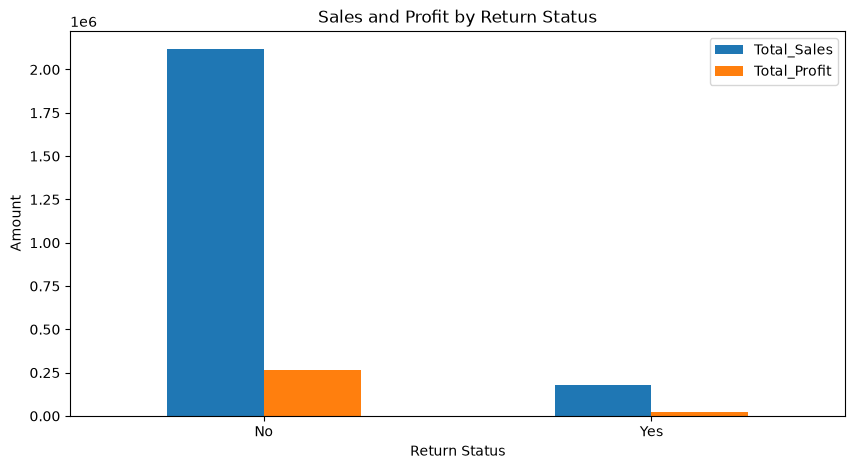

In [184]:
# Compare Sales and Profit by Return Status

return_performance[["Total_Sales", "Total_Profit"]].plot(kind="bar", figsize=(10, 5))

plt.xlabel("Return Status")
plt.ylabel("Amount")
plt.title("Sales and Profit by Return Status")
plt.xticks(rotation=0)
plt.show()

### 4.11.4 Return Rate Across Key Dimensions

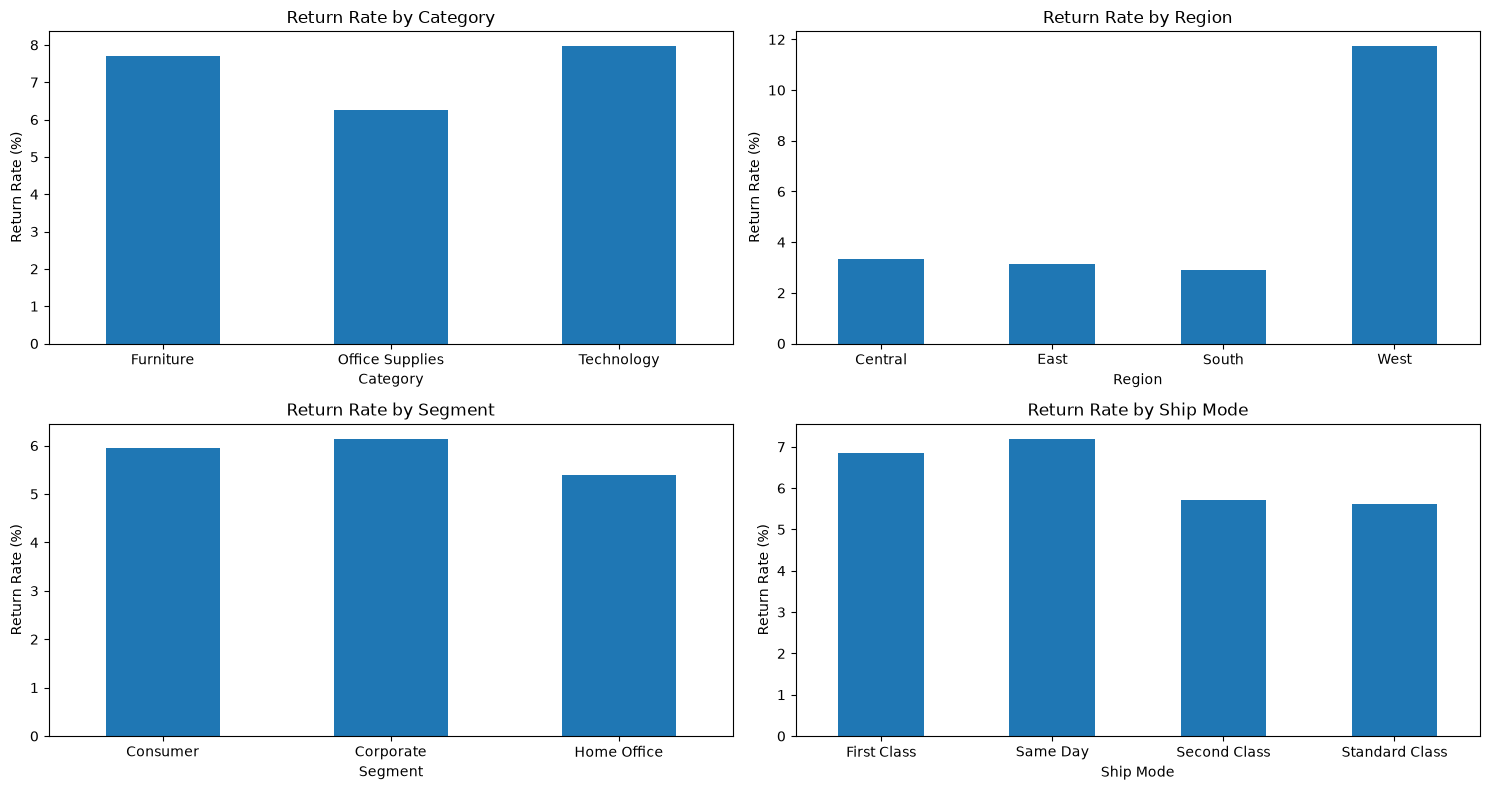

In [185]:
category_returns = orders_returns.groupby("Category")["Order ID"].nunique()
returned_category = orders_returns[orders_returns["Returned"] == "Yes"].groupby("Category")["Order ID"].nunique()
category_returns = returned_category / category_returns * 100

region_returns = orders_returns.groupby("Region")["Order ID"].nunique()
returned_region = orders_returns[orders_returns["Returned"] == "Yes"].groupby("Region")["Order ID"].nunique()
region_returns = returned_region / region_returns * 100

segment_returns = orders_returns.groupby("Segment")["Order ID"].nunique()
returned_segment = orders_returns[orders_returns["Returned"] == "Yes"].groupby("Segment")["Order ID"].nunique()
segment_returns = returned_segment / segment_returns * 100

ship_returns = orders_returns.groupby("Ship Mode")["Order ID"].nunique()
returned_ship = orders_returns[orders_returns["Returned"] == "Yes"].groupby("Ship Mode")["Order ID"].nunique()
ship_returns = returned_ship / ship_returns * 100

# 4.11.4 Returns Analysis

fig, axes = plt.subplots(2, 2, figsize=(15, 8))

# Return Rate by Category
category_returns.plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set_title("Return Rate by Category")
axes[0, 0].set_xlabel("Category")
axes[0, 0].set_ylabel("Return Rate (%)")
axes[0, 0].tick_params(axis="x", rotation=0)

# Return Rate by Region
region_returns.plot(kind="bar", ax=axes[0, 1])
axes[0, 1].set_title("Return Rate by Region")
axes[0, 1].set_xlabel("Region")
axes[0, 1].set_ylabel("Return Rate (%)")
axes[0, 1].tick_params(axis="x", rotation=0)

# Return Rate by Segment
segment_returns.plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("Return Rate by Segment")
axes[1, 0].set_xlabel("Segment")
axes[1, 0].set_ylabel("Return Rate (%)")
axes[1, 0].tick_params(axis="x", rotation=0)

# Return Rate by Ship Mode
ship_returns.plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("Return Rate by Ship Mode")
axes[1, 1].set_xlabel("Ship Mode")
axes[1, 1].set_ylabel("Return Rate (%)")
axes[1, 1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 4.12 Final EDA Summary

In [186]:
# 4.12 Final EDA Summary

logging.info("Generating final EDA summary")

print("=" * 60)
print("FINAL EDA SUMMARY")
print("=" * 60)

# 1. Key Business KPIs
print("\nKPI Summary:")
print("-" * 40)

total_sales = Orders["Sales"].sum()
total_profit = Orders["Profit"].sum()
overall_margin = total_profit / total_sales * 100

print(f"Total Sales: {total_sales:,.2f}")
print(f"Total Profit: {total_profit:,.2f}")
print(f"Overall Profit Margin: {overall_margin:.2f}%")
print(f"Unique Orders: {Orders['Order ID'].nunique():}")
print(f"Unique Customers: {Orders['Customer ID'].nunique():}")
print(f"Unique Products: {Orders['Product ID'].nunique():}")
print(f"Return Rate: {return_rate:.2f}")

# 2. Top-performing dimensions
print("\nTop Performers:")
print("-" * 40)
print("Top Category:",Orders.groupby("Category")["Sales"].sum().idxmax())
print("Top Segment:",Orders.groupby("Segment")["Sales"].sum().idxmax())
print("Top Region:",Orders.groupby("Region")["Sales"].sum().idxmax())

# 3. Key relationships
print("\nKey Relationships:")
print("-" * 40)
discount_margin_corr = Orders["Discount"].corr(Orders["Profit Margin"])
quantity_sales_corr = Orders["Quantity"].corr(Orders["Sales"])
print(f"Discount vs Profit Margin: {discount_margin_corr:.3f}")
print(f"Quantity vs Sales: {quantity_sales_corr:.3f}")

# 4. Outlier summary
print("\nOutlier Summary:")
print("-" * 40)
print(f"Sales potential outliers: {len(sales_outliers)}")
print(f"Profit potential outliers: {len(profit_outliers)}")
print(f"Profit Margin potential outliers: "f"{len(profit_margin_outliers)}")
print("\nOutlier Treatment Decision:")
print("Potential outliers were retained because they")
print("appeared to represent legitimate business transactions.")

# 5. Returns
print("\nReturns:")
print("-" * 40)
print(f"Return Rate: {return_rate:.2f}%")

logging.info("Final EDA summary completed successfully")

2026-08-30 20:30:28,530 | INFO | Generating final EDA summary
FINAL EDA SUMMARY

KPI Summary:
----------------------------------------
Total Sales: 2,297,200.86
Total Profit: 286,397.02
Overall Profit Margin: 12.47%
Unique Orders: 5009
Unique Customers: 793
Unique Products: 1862
Return Rate: 5.91

Top Performers:
----------------------------------------
Top Category: Technology
Top Segment: Consumer
Top Region: West

Key Relationships:
----------------------------------------
Discount vs Profit Margin: -0.864
Quantity vs Sales: 0.201

Outlier Summary:
----------------------------------------
Sales potential outliers: 1167
Profit potential outliers: 1881
Profit Margin potential outliers: 952

Outlier Treatment Decision:
Potential outliers were retained because they
appeared to represent legitimate business transactions.

Returns:
----------------------------------------
Return Rate: 5.91%
2026-08-30 20:30:28,547 | INFO | Final EDA summary completed successfully


# Phase 5: Diagnostic Analysis

In [187]:
Orders.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping Duration', 'Profit Margin', 'Profit per Unit',
       'Sales per Unit', 'Sales Performance Category', 'Order Year',
       'Order Quarter', 'Order Month', 'Order Day', 'Ship Year',
       'Ship Quarter', 'Ship Month', 'Ship Day'],
      dtype='str')

## 5.1 Discount Impact on Profitability

In [188]:
# 5.1 Discount Impact on Profitability

discount_analysis = (Orders.groupby("Discount").agg(Average_Profit=("Profit", "mean"), Total_Profit=("Profit", "sum"), Total_Sales=("Sales", "sum"), Count=("Row ID", "count")))
discount_analysis["Profit Margin"] = (discount_analysis["Total_Profit"] / discount_analysis["Total_Sales"]) * 100

display(discount_analysis)
# Interpretation: Profitability declines noticeably as the discount level increases.

,Average_Profit,Total_Profit,Total_Sales,Count,Profit Margin
Discount,,,,,
0.00,66.900292,320987.6032,1.087908e+06,4798,29.505019
0.10,96.055074,9029.1770,5.436935e+04,94,16.607108
0.15,27.288298,1418.9915,2.755852e+04,52,5.149012
0.20,24.702572,90337.3060,7.645944e+05,3657,11.815063
0.30,-45.679636,-10369.2774,1.032267e+05,227,-10.045155
0.32,-88.560656,-2391.1377,1.449346e+04,27,-16.498047
0.40,-111.927429,-23057.0504,1.164178e+05,206,-19.805437
0.45,-226.646464,-2493.1111,5.484974e+03,11,-45.453472
0.50,-310.703456,-20506.4281,5.891854e+04,66,-34.804712


## 5.2 Loss Drivers

### 5.2.1 Loss-making Transactions

In [189]:
# 5.2.1 Loss-making Transactions

loss_orders = Orders[Orders["Profit"] < 0]
total_losses = loss_orders["Profit"].sum()

print("Loss transactions:", len(loss_orders))
print("Percentage of loss-making transactions:", len(loss_orders) / len(Orders) * 100)
print(f"Total losses: {total_losses}")

Loss transactions: 1871
Percentage of loss-making transactions: 18.721232739643785
Total losses: -156131.2857


### 5.2.2 Losses by Sub-Category

In [190]:
# 5.2.2 Losses by Sub-Category

loss_by_subcategory = (loss_orders.groupby("Sub-Category").agg(Loss_Amount=("Profit", lambda x: -x.sum()), Loss_Transactions=("Order ID", "count"))
                       .sort_values("Loss_Amount", ascending=False))

display(loss_by_subcategory)

,Loss_Amount,Loss_Transactions
Sub-Category,,
Binders,38510.4964,613
Tables,32412.1483,203
Machines,30118.6682,44
Bookcases,12152.2060,109
Chairs,9880.8413,235
Appliances,8629.6412,67
Phones,7530.6235,136
Furnishings,6490.9134,167
Storage,6426.3038,161


### 5.2.3 Largest Loss Drivers Visualization

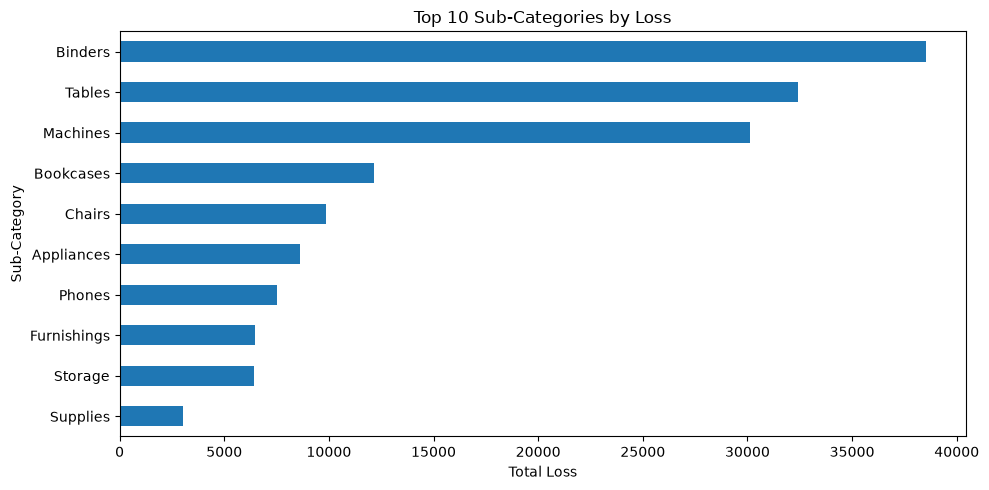

In [191]:
# Visualize largest loss drivers

loss_by_subcategory.head(10)["Loss_Amount"].sort_values().plot(kind="barh", figsize=(10, 5))

plt.xlabel("Total Loss")
plt.ylabel("Sub-Category")
plt.title("Top 10 Sub-Categories by Loss")
plt.tight_layout()
plt.show()

# Binders   → 40000
# Tables    → 33000
# Machines  → 30000

### 5.2.4 Losses by Discount Level

In [192]:
# 5.2.3 Losses by Discount Level

loss_by_discount = (loss_orders.groupby("Discount").agg(Total_Loss=("Profit", lambda x: -x.sum()),Loss_Transactions=("Order ID", "count"))
                    .sort_values("Total_Loss", ascending=False))

display(loss_by_discount)
# High discount levels are associated with substantial losses. Discounts of 70% and 80% recorded the highest total losses

,Total_Loss,Loss_Transactions
Discount,,
0.70,40075.3569,418
0.80,30539.0392,300
0.40,25787.8268,180
0.50,20506.4281,66
0.20,17258.0654,502
0.30,10777.6879,208
0.60,5944.6552,138
0.45,2493.1111,11
0.32,2391.1377,27


## 5.3 Sub-Category Profitability Drivers

In [193]:
# 5.3 Sub-Category Profitability Drivers

subcategory_analysis = (Orders.groupby("Sub-Category").agg(Total_Sales=("Sales", "sum"),Total_Profit=("Profit", "sum"),Average_Discount=("Discount", "mean")))
subcategory_analysis["Profit Margin"] = (subcategory_analysis["Total_Profit"] / subcategory_analysis["Total_Sales"]) * 100

display(subcategory_analysis.sort_values("Profit Margin", ascending=False))
# Labels / Paper / Envelopes → Highest Profit Margins 
# Tables / Bookcases / Supplies → Negative Profit Margins 
# Higher Discount → Lower Profitability → Higher Losses

,Total_Sales,Total_Profit,Average_Discount,Profit Margin
Sub-Category,,,,
Labels,12486.3120,5546.2540,0.068681,44.418672
Paper,78479.2060,34053.5693,0.074891,43.391837
Envelopes,16476.4020,6964.1767,0.080315,42.267582
Copiers,149528.0300,55617.8249,0.161765,37.195585
Fasteners,3024.2800,949.5182,0.082028,31.396504
Accessories,167380.3180,41936.6357,0.078452,25.054700
Art,27118.7920,6527.7870,0.074874,24.071083
Appliances,107532.1610,18138.0054,0.166524,16.867517
Binders,203412.7330,30221.7633,0.372292,14.857361


### 5.3.1 Loss Drivers by Product

In [194]:
# 5.3 Loss Drivers by Product

product_losses = (Orders[Orders["Profit"] < 0].groupby(["Product Name", "Sub-Category"]).agg(
    Total_Profit=("Profit", "sum"),Total_Sales=("Sales", "sum"),Avg_Discount=("Discount", "mean"),Loss_Transactions=("Profit", "count")))

product_losses["Profit Margin"] = (product_losses["Total_Profit"] / product_losses["Total_Sales"]) * 100
display(product_losses.sort_values("Total_Profit").head(10))

,,Total_Profit,Total_Sales,Avg_Discount,Loss_Transactions,Profit Margin
Product Name,Sub-Category,,,,,
Cubify CubeX 3D Printer Double Head Print,Machines,-9239.9692,6299.979,0.700000,2,-146.666667
GBC DocuBind P400 Electric Binding System,Binders,-6859.3896,4899.564,0.766667,3,-140.000000
Lexmark MX611dhe Monochrome Laser Printer,Machines,-5269.9690,13769.919,0.500000,3,-38.271605
GBC Ibimaster 500 Manual ProClick Binding System,Binders,-5098.5660,6696.624,0.716667,6,-76.136364
GBC DocuBind TL300 Electric Binding System,Binders,-4162.0336,4395.251,0.725000,4,-94.693878
Cubify CubeX 3D Printer Triple Head Print,Machines,-3839.9904,7999.980,0.500000,1,-48.000000
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,Binders,-3431.6730,2287.782,0.800000,2,-150.000000
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,Tables,-3107.5272,8264.700,0.350000,4,-37.600000
Ibico EPK-21 Electric Binding System,Binders,-2929.4845,1889.990,0.800000,1,-155.000000


## 5.4 Shipping Performance

In [195]:
# 5.4 Shipping Performance

shipping_analysis = (Orders.groupby("Ship Mode").agg(Average_Shipping_Duration=("Shipping Duration", "mean"), Total_Profit=("Profit", "sum"),Total_Sales=("Sales", "sum")))
shipping_analysis["Profit Margin"] = (shipping_analysis["Total_Profit"] / shipping_analysis["Total_Sales"]) * 100

display(shipping_analysis.sort_values("Average_Shipping_Duration"))
# Shipping performance shows limited variation in profit margin across ship modes.
# Standard Class has the longest average duration, but profit margins remain relatively similar.
# Shipping duration does not appear to be a major driver of profitability.

,Average_Shipping_Duration,Total_Profit,Total_Sales,Profit Margin
Ship Mode,,,,
Same Day,0.044199,15891.7589,1.283631e+05,12.380315
First Class,2.182705,48969.8399,3.514284e+05,13.934513
Second Class,3.237532,57446.6354,4.591936e+05,12.510331
Standard Class,5.006535,164088.7875,1.358216e+06,12.081202


## 5.5 People Performance

In [196]:
# 5.5 People Performance

people_performance = orders_people.groupby(["Person", "Region"]).agg(Total_Sales=("Sales", "sum"), Total_Profit=("Profit", "sum"))
people_performance["Profit Margin"] = (people_performance["Total_Profit"] / people_performance["Total_Sales"]) * 100

display(people_performance.sort_values("Profit Margin", ascending=False))

,,Total_Sales,Total_Profit,Profit Margin
Person,Region,,,
Anna Andreadi,West,725457.8245,108418.4489,14.944831
Chuck Magee,East,678781.2400,91522.7800,13.483399
Cassandra Brandow,South,391721.9050,46749.4303,11.934342
Kelly Williams,Central,501239.8908,39706.3625,7.921629


# Phase 6: Prescriptive Analysis

## 6.1 Discount Recommendations

In [197]:
# Identify profitable and loss-making discount levels

profitable_discounts = discount_analysis[discount_analysis["Profit Margin"] > 0].index.tolist()
loss_making_discounts = discount_analysis[discount_analysis["Profit Margin"] < 0].index.tolist()

print("Profitable discount levels:", profitable_discounts)
print("Loss-making discount levels:", loss_making_discounts)

Profitable discount levels: [0.0, 0.1, 0.15, 0.2]
Loss-making discount levels: [0.3, 0.32, 0.4, 0.45, 0.5, 0.6, 0.7, 0.8]


## 6.2 Product and Sub-Category Recommendations

In [198]:
# 6.2 Product / Sub-Category Recommendations

high_profit_subcategories = subcategory_analysis.sort_values("Profit Margin", ascending=False).head(3)
loss_making_subcategories = subcategory_analysis.sort_values("Profit Margin").head(3)

display(high_profit_subcategories)
display(loss_making_subcategories)
# High-margin sub-categories should be prioritized for growth.
# while loss-making sub-categories should be reviewed for pricing and discount policies.

,Total_Sales,Total_Profit,Average_Discount,Profit Margin
Sub-Category,,,,
Labels,12486.312,5546.2540,0.068681,44.418672
Paper,78479.206,34053.5693,0.074891,43.391837
Envelopes,16476.402,6964.1767,0.080315,42.267582


,Total_Sales,Total_Profit,Average_Discount,Profit Margin
Sub-Category,,,,
Tables,206965.5320,-17725.4811,0.261285,-8.564460
Bookcases,114879.9963,-3472.5560,0.211140,-3.022768
Supplies,46673.5380,-1189.0995,0.076842,-2.547695


## 6.3 Returns Recommendations

In [199]:
# 6.3 Returns Recommendations

print("Highest Category:", category_returns.idxmax(), category_returns.max())
print("Highest Region:", region_returns.idxmax(), region_returns.max())
print("Highest Segment:", segment_returns.idxmax(), segment_returns.max())
print("Highest Ship Mode:", ship_returns.idxmax(), ship_returns.max())
# Focus return reduction efforts on the areas with the highest return rates.

Highest Category: Technology 7.966321243523317
Highest Region: West 11.731843575418994
Highest Segment: Corporate 6.142668428005284
Highest Ship Mode: Same Day 7.196969696969697


### 7.2 Final Business Recommendations

1. Discount
Keep discounts at lower levels where possible, especially avoid aggressive discounts of 30%+.

2. Products
Prioritize high-margin sub-categories such as Labels, Paper, and Envelopes.
Review loss-making sub-categories such as Tables, Bookcases, and Supplies.

3. Shipping
Shipping duration showed limited impact on profitability.
No major profitability-related changes are recommended.

4. Returns
Focus return-reduction efforts on areas with the highest return rates.

# Phase 7: Performance Optimization

## 7.1 Memory Usage Assessment


In [200]:
# 7.1 Memory Usage Assessment

print("Orders Memory Usage:")
print("-" * 40)
Orders.info(memory_usage="deep")

Orders Memory Usage:
----------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 34 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Row ID                      9994 non-null   int64         
 1   Order ID                    9994 non-null   str           
 2   Order Date                  9994 non-null   datetime64[us]
 3   Ship Date                   9994 non-null   datetime64[us]
 4   Ship Mode                   9994 non-null   str           
 5   Customer ID                 9994 non-null   str           
 6   Customer Name               9994 non-null   str           
 7   Segment                     9994 non-null   str           
 8   Country/Region              9994 non-null   str           
 9   City                        9994 non-null   str           
 10  State                       9994 non-null   str           
 11  Posta

In [201]:
print("\nPeople Memory Usage:")
print("-" * 40)
People.info(memory_usage="deep")


People Memory Usage:
----------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Person  4 non-null      str  
 1   Region  4 non-null      str  
dtypes: str(2)
memory usage: 599.0 bytes


In [202]:
print("\nReturns Memory Usage:")
print("-" * 40)
Returns.info(memory_usage="deep")


Returns Memory Usage:
----------------------------------------
<class 'pandas.DataFrame'>
Index: 296 entries, 0 to 798
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Returned  296 non-null    str  
 1   Order ID  296 non-null    str  
dtypes: str(2)
memory usage: 35.6 KB


## 7.2 Drop Unnecessary Columns

In [203]:
Orders.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping Duration', 'Profit Margin', 'Profit per Unit',
       'Sales per Unit', 'Sales Performance Category', 'Order Year',
       'Order Quarter', 'Order Month', 'Order Day', 'Ship Year',
       'Ship Quarter', 'Ship Month', 'Ship Day'],
      dtype='str')

In [204]:
# 7.2 Drop Unnecessary Columns

logging.info("Removing unnecessary columns for export")

Orders = Orders.drop(columns=[
    "Order Year",
    "Order Quarter",
    "Order Month",
    "Order Day",
    "Ship Year",
    "Ship Quarter",
    "Ship Month",
    "Ship Day"
])

logging.info("Unnecessary columns removed successfully")

2026-08-30 20:30:29,268 | INFO | Removing unnecessary columns for export
2026-08-30 20:30:29,275 | INFO | Unnecessary columns removed successfully


## 7.3 Optimize Data Types


In [205]:
logging.info("Optimizing categorical data types")

Orders["Ship Mode"] = Orders["Ship Mode"].astype("category")
Orders["Segment"] = Orders["Segment"].astype("category")
Orders["Region"] = Orders["Region"].astype("category")
Orders["Category"] = Orders["Category"].astype("category")
Orders["Sub-Category"] = Orders["Sub-Category"].astype("category")

logging.info("Categorical data types optimized successfully")

2026-08-30 20:30:29,316 | INFO | Optimizing categorical data types
2026-08-30 20:30:29,345 | INFO | Categorical data types optimized successfully


## 7.4 Downcast Numeric Data

In [206]:
# 7.4 Downcast Numeric Data

logging.info("Optimizing numeric data types")

Orders["Row ID"] = Orders["Row ID"].astype("int32")
Orders["Quantity"] = Orders["Quantity"].astype("int8")

Orders["Sales"] = Orders["Sales"].astype("float32")
Orders["Discount"] = Orders["Discount"].astype("float32")
Orders["Profit"] = Orders["Profit"].astype("float32")
Orders["Profit Margin"] = Orders["Profit Margin"].astype("float32")
Orders["Profit per Unit"] = Orders["Profit per Unit"].astype("float32")
Orders["Sales per Unit"] = Orders["Sales per Unit"].astype("float32")

logging.info("Numeric data types optimized successfully")

2026-08-30 20:30:29,363 | INFO | Optimizing numeric data types
2026-08-30 20:30:29,368 | INFO | Numeric data types optimized successfully


## 7.5 Memory After

In [207]:
# 7.5 Memory After
Orders.info(memory_usage=True)

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Row ID                      9994 non-null   int32         
 1   Order ID                    9994 non-null   str           
 2   Order Date                  9994 non-null   datetime64[us]
 3   Ship Date                   9994 non-null   datetime64[us]
 4   Ship Mode                   9994 non-null   category      
 5   Customer ID                 9994 non-null   str           
 6   Customer Name               9994 non-null   str           
 7   Segment                     9994 non-null   category      
 8   Country/Region              9994 non-null   str           
 9   City                        9994 non-null   str           
 10  State                       9994 non-null   str           
 11  Postal Code                 9994 non-null   str           
 12  Reg

In [208]:
memory_before = 9.3
memory_after = 1.2

Memory_Reduction = (memory_before - memory_after)
reduction_percentage = Memory_Reduction / memory_before * 100

print(f"Memory Reduction: {Memory_Reduction:.1f}")
print(f"Memory Reduction percentage: {reduction_percentage:.1f}%")

Memory Reduction: 8.1
Memory Reduction percentage: 87.1%


# Phase 8: Reporting and Export

## 8.1 KPI Summary

In [219]:
# 8.1 KPI Summary

logging.info("Generating KPI summary")

kpi_summary = (
    f"Total Sales: {total_sales:,.2f}\n"
    f"Total Profit: {total_profit:,.2f}\n"
    f"Overall Profit Margin: {overall_margin:.2f}%\n"
    f"Unique Orders: {Orders['Order ID'].nunique()}\n"
    f"Unique Customers: {Orders['Customer ID'].nunique()}\n"
    f"Unique Products: {Orders['Product ID'].nunique()}\n"
    f"Return Rate: {return_rate:.2f}%"
)

print("KPI Summary:")
print("-" * 40)
print(kpi_summary)

logging.info("KPI summary generated successfully")

2026-08-30 20:39:31,216 | INFO | Generating KPI summary
KPI Summary:
----------------------------------------
Total Sales: 2,297,200.86
Total Profit: 286,397.02
Overall Profit Margin: 12.47%
Unique Orders: 5009
Unique Customers: 793
Unique Products: 1862
Return Rate: 5.91%
2026-08-30 20:39:31,230 | INFO | KPI summary generated successfully


## 8.2 Analytical Report


In [217]:
# 8.2 Analytical Report

logging.info("Generating analytical report")

report = (
    f"Top Category: {Orders.groupby('Category')['Sales'].sum().idxmax()}\n"
    f"Top Segment: {Orders.groupby('Segment')['Sales'].sum().idxmax()}\n"
    f"Top Region: {Orders.groupby('Region')['Sales'].sum().idxmax()}\n"
    f"Discount Impact: Discount vs Profit Margin correlation = {discount_margin_corr:.3f}\n"
    f"Quantity and Sales: Quantity vs Sales correlation = {quantity_sales_corr:.3f}\n"
    f"Main Loss Driver: {loss_by_subcategory.index[0]}\n"
    f"Highest Profit Margin: {subcategory_analysis['Profit Margin'].idxmax()}\n"
    f"Returns: {category_returns.idxmax()} has the highest return rate by category"
)

print("Analytical Report:")
print("-" * 40)
print(report)

logging.info("Analytical report generated successfully")

2026-08-30 20:38:12,391 | INFO | Generating analytical report
Analytical Report:
----------------------------------------
Top Category: Technology
Top Segment: Consumer
Top Region: West
Discount Impact: Discount vs Profit Margin correlation = -0.864
Quantity and Sales: Quantity vs Sales correlation = 0.201
Main Loss Driver: Binders
Highest Profit Margin: Labels
Returns: Technology has the highest return rate by category
2026-08-30 20:38:12,403 | INFO | Analytical report generated successfully


In [226]:
with open("analytical_report.txt", "w", encoding="utf-8") as file:
    file.write(kpi_summary + "\n")
    file.write("-" * 40 + "\n")
    file.write(report)

## 8.3 Cleaned Data Export


In [ ]:
# 8.3 Cleaned Data Export

logging.info("Exporting cleaned datasets")

with pd.ExcelWriter("cleaned Sample - Superstore 2019.xlsx") as writer:
    Orders.to_excel(writer, sheet_name="Orders", index=False)
    People.to_excel(writer, sheet_name="People", index=False)
    Returns.to_excel(writer, sheet_name="Returns", index=False)

logging.info("Cleaned datasets exported successfully")

2026-08-30 20:26:34,783 | INFO | Exporting cleaned datasets
2026-08-30 20:26:40,608 | INFO | Cleaned datasets exported successfully


In [ ]:
# 8.2 Analytical Report

logging.info("Generating analytical report")

report = {
    "Top Category": Orders.groupby("Category")["Sales"].sum().idxmax(),
    "Top Segment": Orders.groupby("Segment")["Sales"].sum().idxmax(),
    "Top Region": Orders.groupby("Region")["Sales"].sum().idxmax(),
    "Discount Impact": f"Discount vs Profit Margin correlation = {discount_margin_corr:.3f}",
    "Quantity and Sales": f"Quantity vs Sales correlation = {quantity_sales_corr:.3f}",
    "Main Loss Driver": loss_by_subcategory.index[0],
    "Highest Profit Margin": subcategory_analysis["Profit Margin"].idxmax(),
    "Returns": f"{category_returns.idxmax()} has the highest return rate by category"
}

print("Analytical Report:")
print("-" * 40)

for key, value in report.items():
    print(f"{key}: {value}")

logging.info("Analytical report generated successfully")

# Final Project Summary
This project covered data loading, data quality assessment, cleaning, feature engineering, EDA, diagnostic analysis, and prescriptive analysis.

### Key Findings
- Higher discounts are strongly associated with lower profit margins.
- High discount levels are linked to substantial losses.
- Tables, Bookcases, and Supplies show negative overall profit margins.
- Labels, Paper, and Envelopes have the highest profit margins.
- Shipping duration does not appear to be a major driver of profitability.
- Return rates vary across the main business dimensions.

### Key Recommendations
- Avoid aggressive discounting, especially at 30% or higher.
- Prioritize high-margin sub-categories and review loss-making products.
- Maintain the current shipping approach unless other operational issues are identified.
- Investigate areas with relatively high return rates.